# 🏭 NEU-DET — Full EDA + Image Enhancement Filters + BBox Before/After

> **Dataset:** NEU Surface Defect Database (NEU-DET)  
> **Classes:** 6 defect types · 300 images each · **1,800 images total**  
> **Resolution:** 200×200 px · Grayscale · PASCAL VOC XML annotations  
> **Purpose:** Comprehensive EDA + multiple enhancement filters with bounding-box comparison  

---

## 📑 Table of Contents

1. **Step 1** — Class Distribution & Bounding-Box Counts
2. **Step 2** — BBox Geometry Analysis & YOLO Anchor Generation
3. **Step 3** — Spatial Heatmaps + Centroid Distribution
4. **Step 4** — Pixel Intensity & Texture Complexity Analysis
5. **Step 5** — Image Enhancement Filters (CLAHE, Gaussian, Bilateral, Unsharp Mask, Top-Hat)
6. **Step 6** — BBox Visualization: **Original vs Enhanced** Side-by-Side
7. **Step 7** — Quantitative Filter Comparison (Contrast, Sharpness, SNR)
8. **Step 8** — Sobel Edge Analysis & Augmentation Strategy
9. **Summary** — Architecture Recommendations

---
## ⚙️ Environment Setup

Import all required libraries, configure plot aesthetics, and load the full NEU-DET dataset (1,800 images + annotations).

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xml.etree.ElementTree as ET
from pathlib import Path
from sklearn.cluster import KMeans
from scipy.ndimage import gaussian_filter

# ── Global Plot Aesthetics ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']       = 130
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'

# ── Dataset Path ──────────────────────────────────────────────────────────────
DATA_DIR  = Path('./datasets/NEU-DET')
ANNOT_DIR = DATA_DIR / 'ANNOTATIONS'

# ── Load ALL 1,800 images ──────────────────────────────────────────────────
all_imgs = list((DATA_DIR / 'train' / 'images').glob('*.jpg')) + \
           list((DATA_DIR / 'valid' / 'images').glob('*.jpg'))

# ── Build class → image list ───────────────────────────────────────────────
class_images = {}
for p in all_imgs:
    cls = '_'.join(p.stem.split('_')[:-1]).lower()
    class_images.setdefault(cls, []).append(p)

display_classes = sorted(class_images.keys())

# ── Parse ALL bounding boxes from XML ──────────────────────────────────────
data_bboxes = []
for xml_path in ANNOT_DIR.glob('*.xml'):
    try:
        root = ET.parse(xml_path).getroot()
        fname = root.find('filename').text
        for obj in root.findall('object'):
            cls  = obj.find('name').text.lower().strip()
            bb   = obj.find('bndbox')
            xmin = int(bb.find('xmin').text)
            ymin = int(bb.find('ymin').text)
            xmax = int(bb.find('xmax').text)
            ymax = int(bb.find('ymax').text)
            data_bboxes.append({
                'Class': cls, 'File': fname,
                'Width': xmax - xmin, 'Height': ymax - ymin,
                'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax
            })
    except Exception:
        pass

df_bbox = pd.DataFrame(data_bboxes)
df_bbox['AspectRatio'] = df_bbox['Width'] / df_bbox['Height'].replace(0, 1)
df_bbox['Area']        = df_bbox['Width'] * df_bbox['Height']
df_bbox['cx']          = (df_bbox['xmin'] + df_bbox['xmax']) / 2
df_bbox['cy']          = (df_bbox['ymin'] + df_bbox['ymax']) / 2

print('✅ Environment ready.')
print(f'   DATA_DIR = {DATA_DIR.absolute()}')
print(f'   Total images loaded: {len(all_imgs)}')
print(f'   Total bounding boxes parsed: {len(df_bbox)}')
print(f'   Classes: {display_classes}')
for cls, imgs in sorted(class_images.items()):
    print(f'   {cls:20s}: {len(imgs)} images')

✅ Environment ready.
   DATA_DIR = D:\priject tarek\EDAAA-20260612T165457Z-3-001\EDAAA\datasets\NEU-DET
   Total images loaded: 1800
   Total bounding boxes parsed: 4189
   Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
   crazing             : 300 images
   inclusion           : 300 images
   patches             : 300 images
   pitted_surface      : 300 images
   rolled-in_scale     : 300 images
   scratches           : 300 images


---
## 📊 Step 1: Class Distribution & Bounding-Box Counts

Verify image count per class (expected: 300 each — perfectly balanced) and count bounding boxes from all 1,800 XML annotations.

Each image can contain **multiple** bounding boxes, so bbox count ≥ image count.

🛑 Filtering out 'scratches' class...


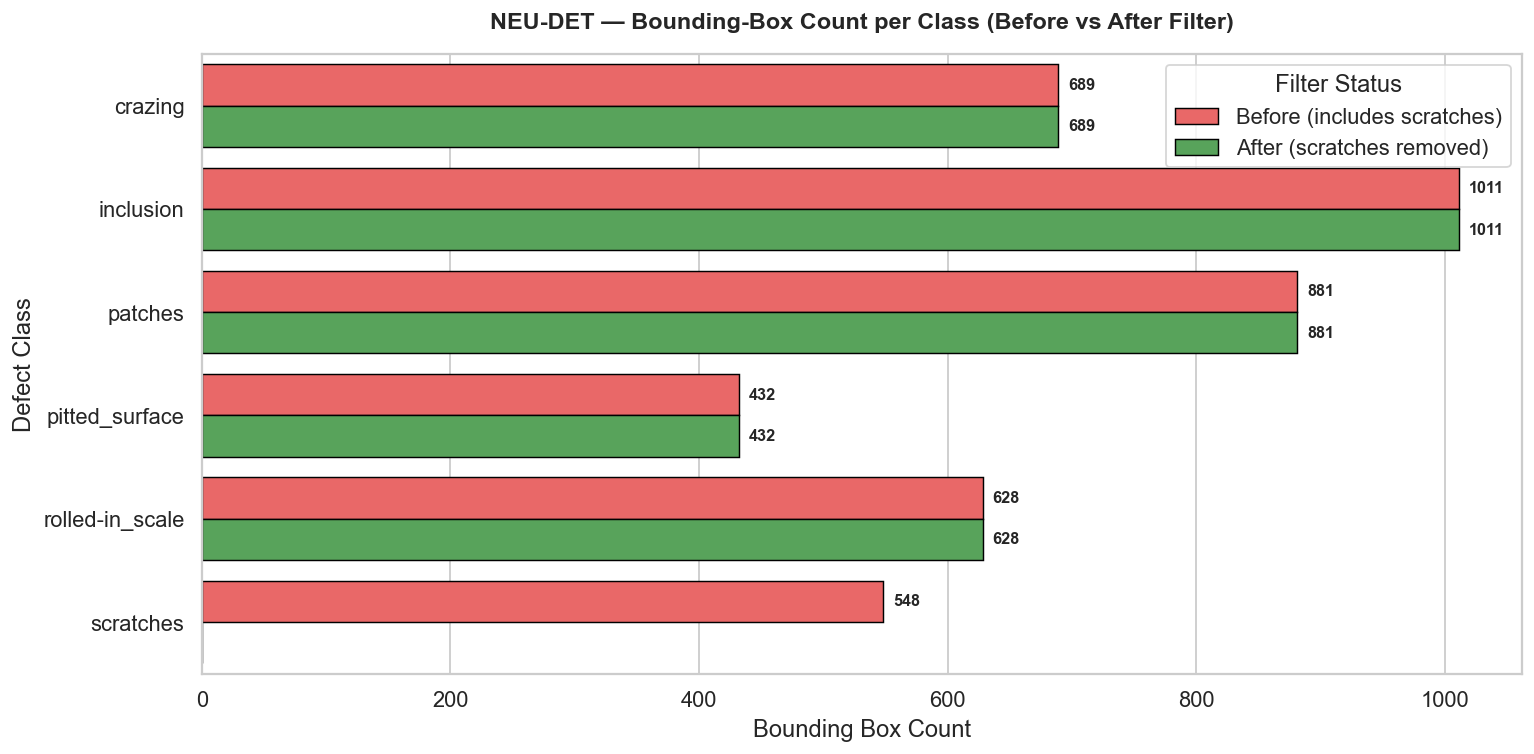


📋 Summary Table (After Filtering):
          Class  Images  BBoxes  Avg BBoxes/Image
        crazing     300     689              2.30
      inclusion     300    1011              3.37
        patches     300     881              2.94
 pitted_surface     300     432              1.44
rolled-in_scale     300     628              2.09

📦 Total bounding boxes (Before): 4189
📦 Total bounding boxes (After):  3641


In [2]:
# ── Image count + BBox count per class (BEFORE FILTERING) ────────────────
class_img_counts_before = {cls: len(imgs) for cls, imgs in class_images.items()}
df_img_before = pd.DataFrame(list(class_img_counts_before.items()), columns=['Class', 'Images'])

class_bbox_counts_before = df_bbox.groupby('Class').size().reset_index(name='BBoxes')
df_classes_before = df_img_before.merge(class_bbox_counts_before, on='Class')

# ── Filter out "scratches" class ─────────────────────────────────────────
print("🛑 Filtering out 'scratches' class...")
display_classes = [c for c in display_classes if c != 'scratches']
del class_images['scratches']
all_imgs = [p for p in all_imgs if 'scratches' not in p.stem.lower()]
df_bbox = df_bbox[df_bbox['Class'] != 'scratches'].copy()

# ── Image count + BBox count per class (AFTER FILTERING) ─────────────────
class_img_counts = {cls: len(imgs) for cls, imgs in class_images.items()}
df_img = pd.DataFrame(list(class_img_counts.items()), columns=['Class', 'Images'])

class_bbox_counts = df_bbox.groupby('Class').size().reset_index(name='BBoxes')
df_classes = df_img.merge(class_bbox_counts, on='Class')
df_classes['Avg BBoxes/Image'] = (df_classes['BBoxes'] / df_classes['Images']).round(2)
df_classes = df_classes.sort_values('Images', ascending=False).reset_index(drop=True)

# ── Plot Before and After Bounding Box Counts ─────────────────────────────
df_before = class_bbox_counts_before.copy()
df_before['Filter Status'] = 'Before (includes scratches)'
df_after = class_bbox_counts.copy()
df_after['Filter Status'] = 'After (scratches removed)'

# In the 'After' dataset, 'scratches' will be missing, let's add it as 0 to show the drop properly
df_after = pd.concat([df_after, pd.DataFrame([{'Class': 'scratches', 'BBoxes': 0, 'Filter Status': 'After (scratches removed)'}])], ignore_index=True)

df_compare = pd.concat([df_before, df_after], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_compare, x='BBoxes', y='Class', hue='Filter Status',
            palette=['#FF5252', '#4CAF50'], edgecolor='black', linewidth=0.8, ax=ax)
ax.set_title('NEU-DET — Bounding-Box Count per Class (Before vs After Filter)', pad=14)
ax.set_xlabel('Bounding Box Count')
ax.set_ylabel('Defect Class')
for p in ax.patches:
    if p.get_width() > 0:
        ax.text(p.get_width() + 8, p.get_y() + p.get_height() / 2,
                f'{int(p.get_width())}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📋 Summary Table (After Filtering):')
print(df_classes.to_string(index=False))
print(f'\n📦 Total bounding boxes (Before): {df_before["BBoxes"].sum()}')
print(f'📦 Total bounding boxes (After):  {df_classes["BBoxes"].sum()}')


---
## 📐 Step 2: BBox Geometry Analysis & YOLO Anchor Generation

Analyse all bounding boxes from 1,800 XMLs:
- **Scatter plot:** Width vs Height coloured by class
- **Aspect ratio KDE:** Eelongation per defect type
- **K-Means (k=9):** Optimal YOLO anchor boxes

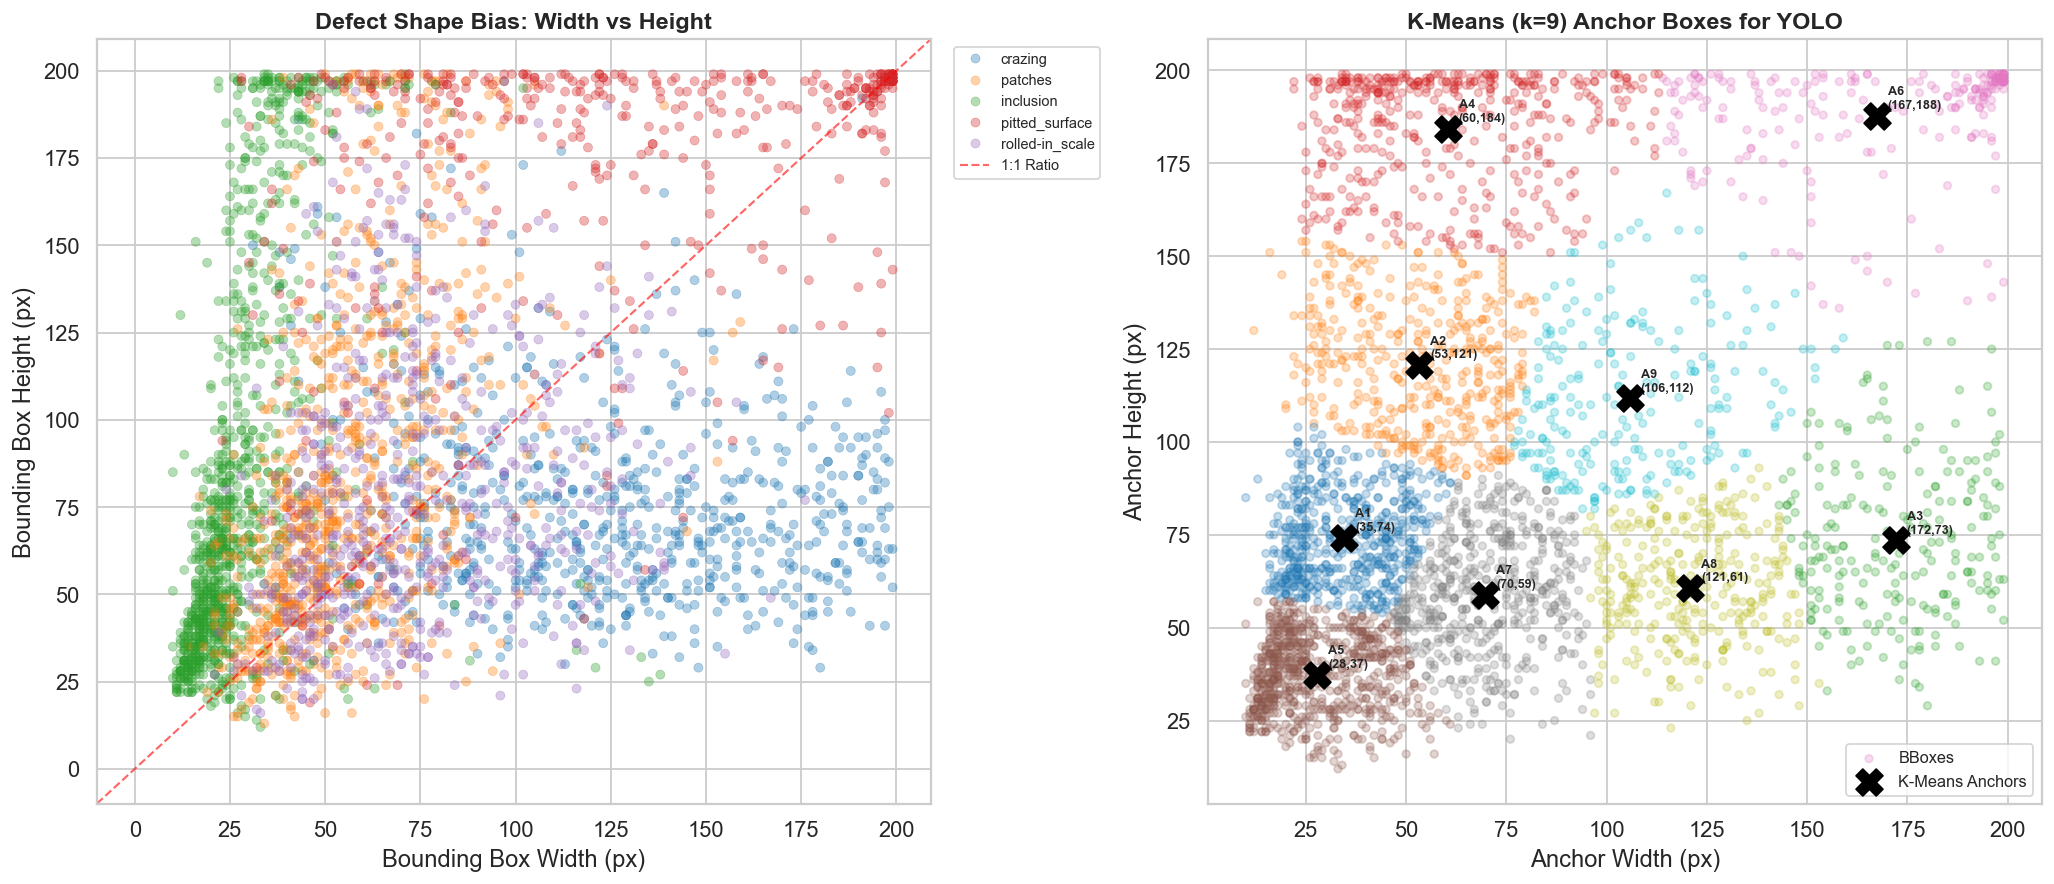

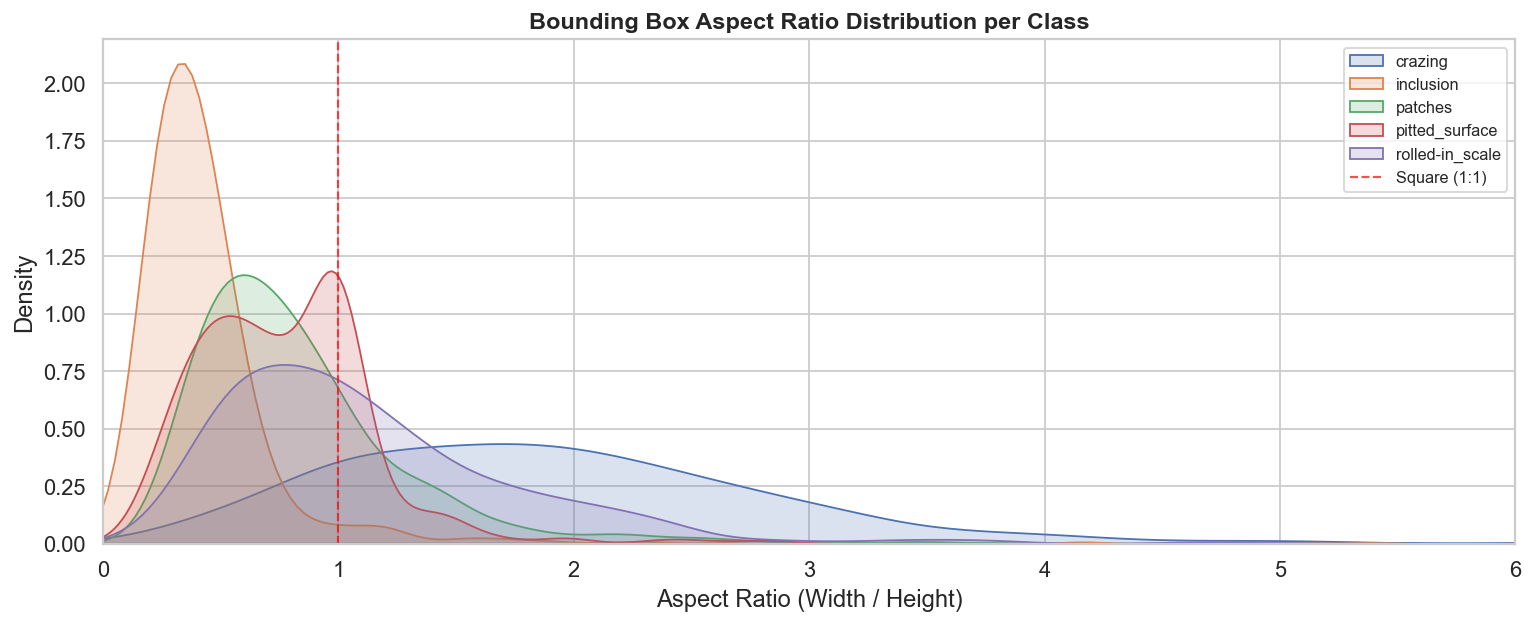


📌 K-Means Anchor Boxes (sorted by area):
  Anchor 1: W=27.8px  H=37.4px  Area=1039px²
  Anchor 2: W=34.5px  H=74.2px  Area=2562px²
  Anchor 3: W=69.8px  H=58.9px  Area=4106px²
  Anchor 4: W=53.2px  H=120.7px  Area=6426px²
  Anchor 5: W=120.8px  H=60.7px  Area=7333px²
  Anchor 6: W=60.4px  H=184.4px  Area=11140px²
  Anchor 7: W=105.8px  H=111.8px  Area=11821px²
  Anchor 8: W=172.1px  H=73.5px  Area=12648px²
  Anchor 9: W=167.4px  H=187.8px  Area=31442px²

📋 BBox Statistics per Class:
                Width             Height             AspectRatio            Area                
                  min  max   mean    min  max   mean         min  max mean   min    max     mean
Class                                                                                           
crazing            31  199  125.1     29  197   75.3         0.2  6.2  1.9  2240  36672   9236.1
inclusion          10  138   28.5     12  199   85.1         0.1  5.4  0.4   242  19890   2821.2
patches            14  159

In [3]:
# ── Scatter Plot + K-Means Anchors ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.scatterplot(data=df_bbox, x='Width', y='Height', hue='Class',
                alpha=0.35, palette='tab10', s=25, edgecolor=None, ax=axes[0])
axes[0].axline((0, 0), slope=1, color='red', linestyle='--',
               linewidth=1.2, alpha=0.6, label='1:1 Ratio')
axes[0].set_title('Defect Shape Bias: Width vs Height')
axes[0].set_xlabel('Bounding Box Width (px)')
axes[0].set_ylabel('Bounding Box Height (px)')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

wh     = df_bbox[['Width', 'Height']].values
kmeans = KMeans(n_clusters=9, random_state=42, n_init='auto')
kmeans.fit(wh)
anchors = kmeans.cluster_centers_

axes[1].scatter(wh[:, 0], wh[:, 1], c=kmeans.labels_, cmap='tab10',
                alpha=0.25, s=18, edgecolor=None, label='BBoxes')
axes[1].scatter(anchors[:, 0], anchors[:, 1],
                marker='X', s=220, c='black', zorder=5, label='K-Means Anchors')
for i, (w, h) in enumerate(anchors):
    axes[1].annotate(f'A{i+1}\n({w:.0f},{h:.0f})', (w, h),
                     textcoords='offset points', xytext=(6, 4),
                     fontsize=7, fontweight='bold')
axes[1].set_title('K-Means (k=9) Anchor Boxes for YOLO')
axes[1].set_xlabel('Anchor Width (px)')
axes[1].set_ylabel('Anchor Height (px)')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Aspect Ratio KDE ──────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))
for cls in sorted(df_bbox['Class'].unique()):
    subset = df_bbox[df_bbox['Class'] == cls]['AspectRatio']
    sns.kdeplot(subset, ax=ax2, label=cls, fill=True, alpha=0.2)
ax2.axvline(1.0, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Square (1:1)')
ax2.set_title('Bounding Box Aspect Ratio Distribution per Class')
ax2.set_xlabel('Aspect Ratio (Width / Height)')
ax2.set_ylabel('Density')
ax2.set_xlim(0, 6)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\n📌 K-Means Anchor Boxes (sorted by area):')
for i, (w, h) in enumerate(sorted(anchors, key=lambda x: x[0] * x[1])):
    print(f'  Anchor {i+1}: W={w:.1f}px  H={h:.1f}px  Area={w*h:.0f}px²')

print('\n📋 BBox Statistics per Class:')
stats = df_bbox.groupby('Class')[['Width', 'Height', 'AspectRatio', 'Area']] \
               .agg(['min', 'max', 'mean']).round(1)
print(stats.to_string())

---
## 🗺️ Step 3: Spatial Heatmaps + Centroid Distribution

Accumulate all bounding boxes into a 200×200 spatial grid.
Hot zones reveal bias from the rolling-mill process.

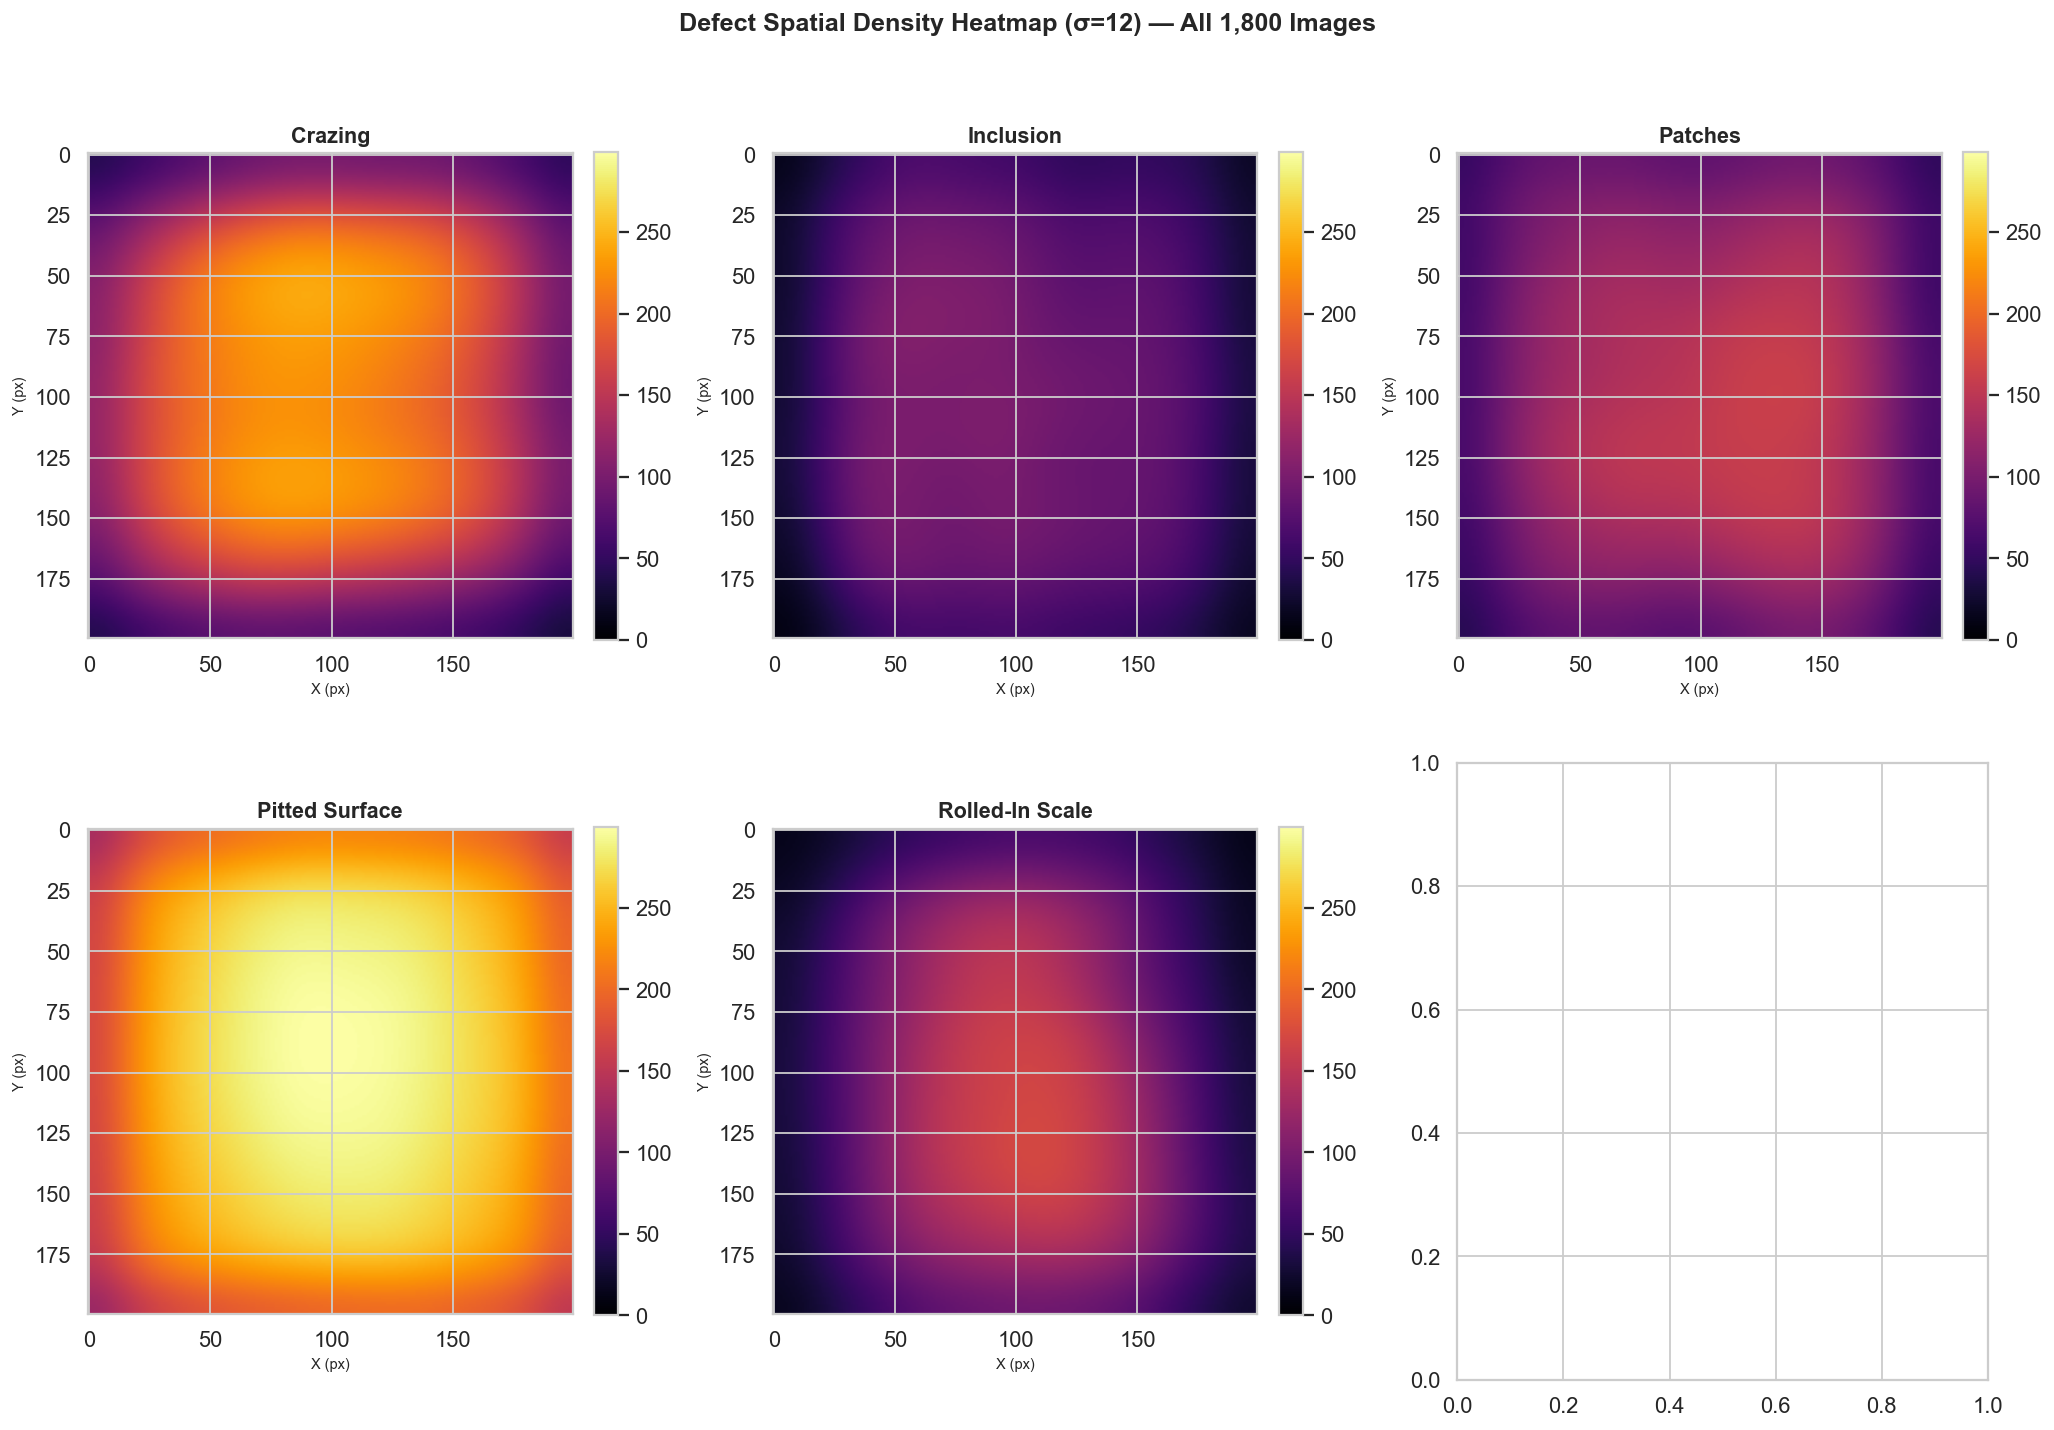

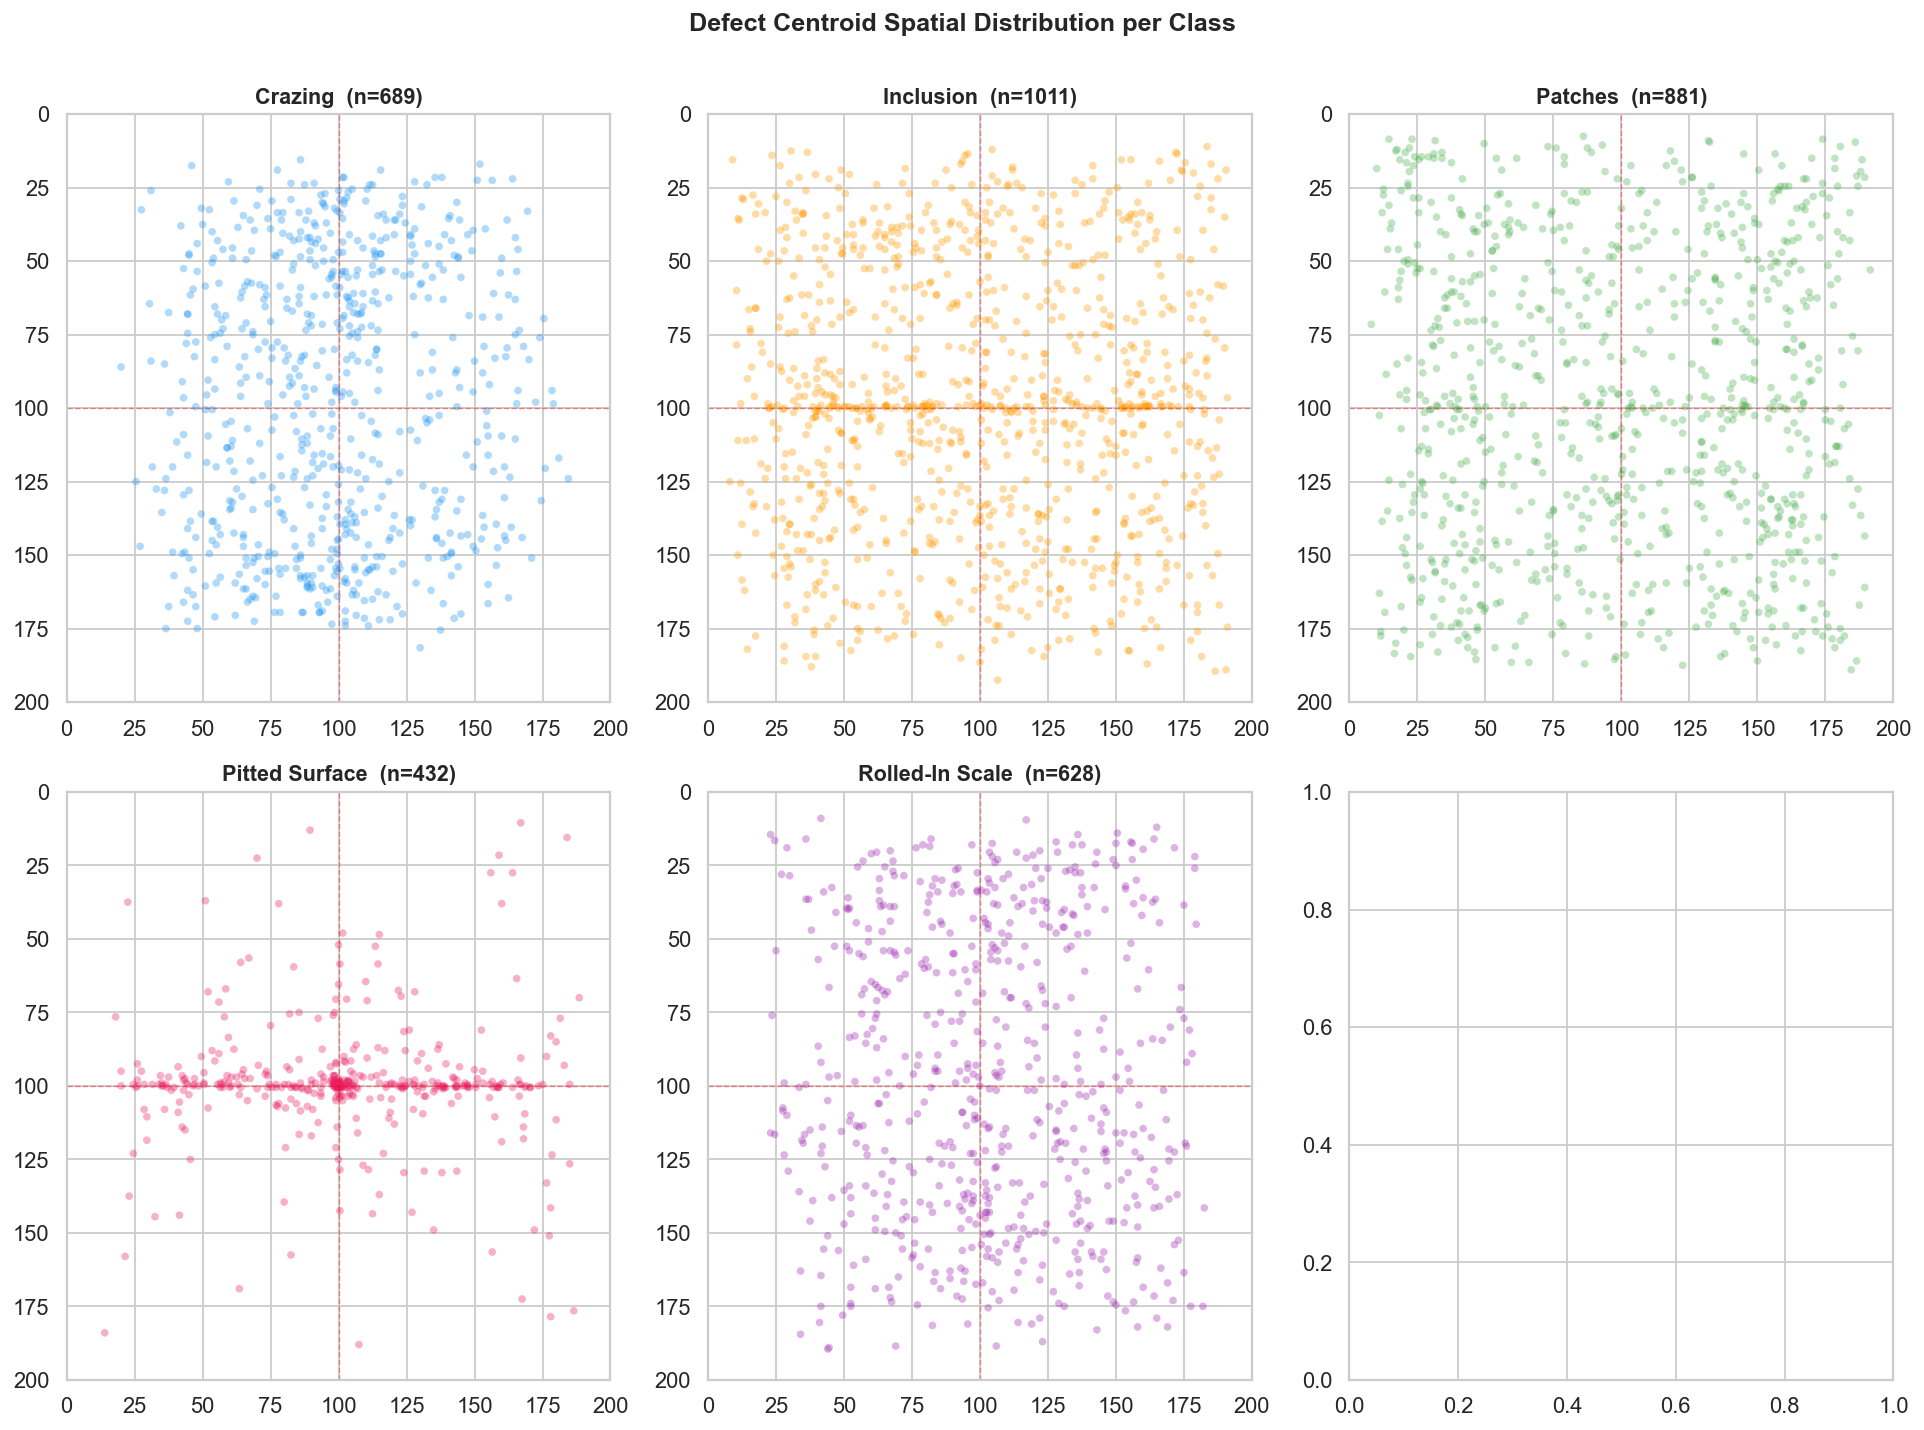

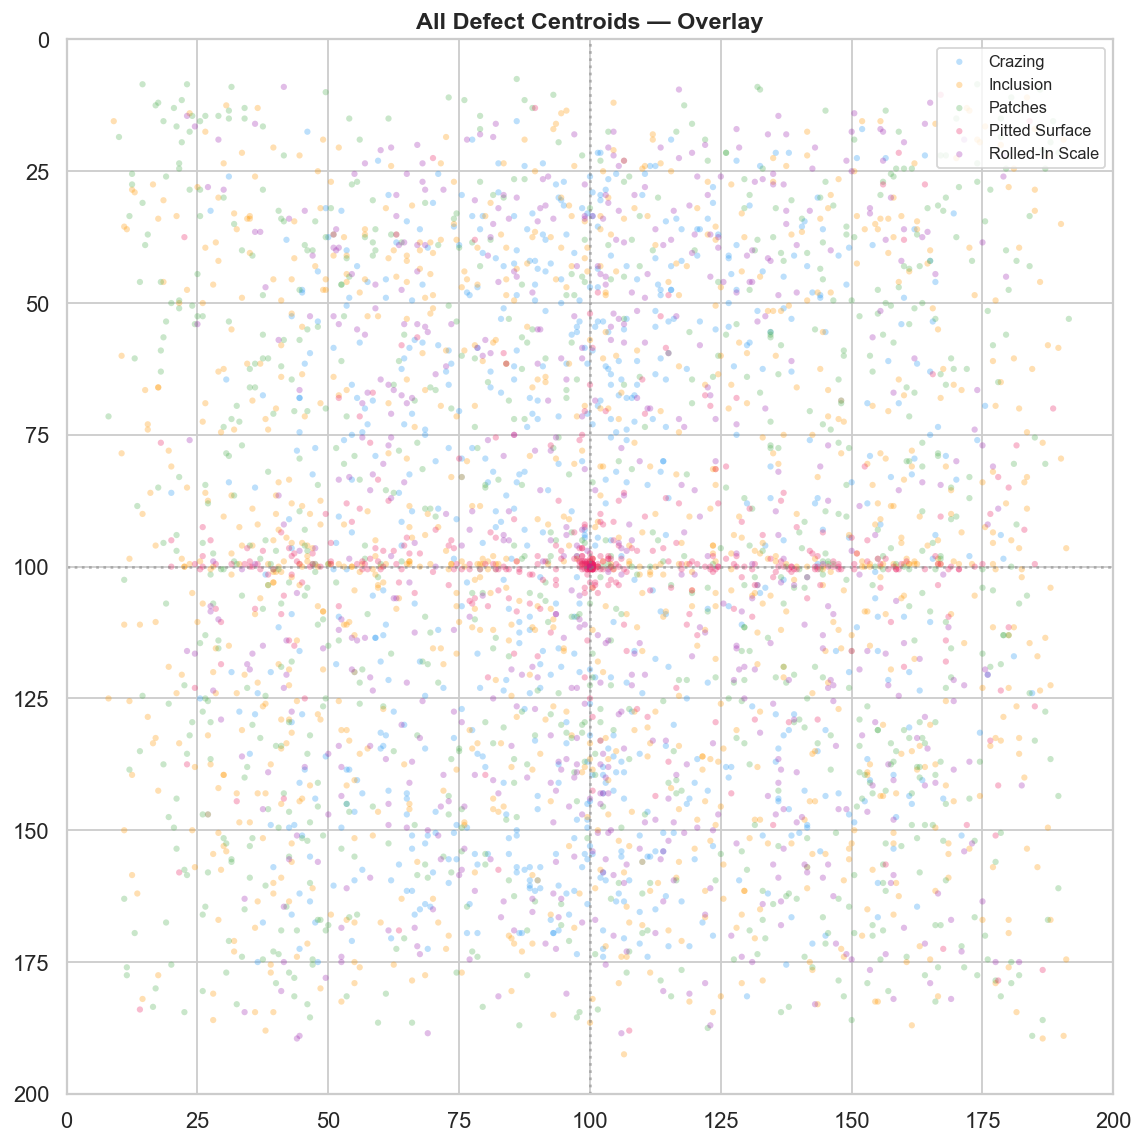

📊 Spatial summary:
  crazing             : cx_mean=98.4  cy_mean=97.7  cx_std=34.4  cy_std=46.0
  inclusion           : cx_mean=98.7  cy_mean=98.0  cx_std=50.0  cy_std=45.3
  patches             : cx_mean=99.1  cy_mean=98.1  cx_std=52.6  cy_std=50.6
  pitted_surface      : cx_mean=102.4  cy_mean=99.1  cx_std=39.1  cy_std=21.0
  rolled-in_scale     : cx_mean=103.1  cy_mean=97.4  cx_std=38.8  cy_std=49.7


In [4]:
unique_classes = sorted(df_bbox['Class'].unique())
COLORS6 = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0', '#00BCD4']

# ── Spatial Heatmaps ──────────────────────────────────────────────────────
heatmaps_raw    = {cls: np.zeros((200, 200)) for cls in unique_classes}
heatmaps_smooth = {}

for row in df_bbox.itertuples():
    y1, y2 = max(0, row.ymin), min(200, row.ymax)
    x1, x2 = max(0, row.xmin), min(200, row.xmax)
    heatmaps_raw[row.Class][y1:y2, x1:x2] += 1

for cls in unique_classes:
    heatmaps_smooth[cls] = gaussian_filter(heatmaps_raw[cls], sigma=12)

vmax = max(h.max() for h in heatmaps_smooth.values())

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle('Defect Spatial Density Heatmap (σ=12) — All 1,800 Images',
             fontsize=14, fontweight='bold', y=1.0)
for i, cls in enumerate(unique_classes):
    ax = axes[i // 3, i % 3]
    im = ax.imshow(heatmaps_smooth[cls], cmap='inferno', origin='upper', vmin=0, vmax=vmax)
    ax.set_title(cls.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel('X (px)', fontsize=8)
    ax.set_ylabel('Y (px)', fontsize=8)
plt.tight_layout()
plt.show()

# ── Centroid Scatter ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 11))
fig2.suptitle('Defect Centroid Spatial Distribution per Class',
              fontsize=14, fontweight='bold', y=1.0)
for i, cls in enumerate(unique_classes):
    ax = axes2[i // 3, i % 3]
    sub = df_bbox[df_bbox['Class'] == cls]
    ax.scatter(sub['cx'], sub['cy'], alpha=0.35, s=18, color=COLORS6[i], edgecolors='none')
    ax.set_xlim(0, 200)
    ax.set_ylim(200, 0)
    ax.set_title(f'{cls.replace("_", " ").title()}  (n={len(sub)})', fontsize=12, fontweight='bold')
    ax.axhline(100, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
    ax.axvline(100, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
plt.tight_layout()
plt.show()

# ── Combined Overlay ──────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(9, 9))
for i, cls in enumerate(unique_classes):
    sub = df_bbox[df_bbox['Class'] == cls]
    ax3.scatter(sub['cx'], sub['cy'], alpha=0.3, s=12, color=COLORS6[i],
                label=cls.replace('_', ' ').title(), edgecolors='none')
ax3.set_xlim(0, 200)
ax3.set_ylim(200, 0)
ax3.set_title('All Defect Centroids — Overlay', fontsize=13, fontweight='bold')
ax3.axhline(100, color='gray', linestyle=':', alpha=0.5)
ax3.axvline(100, color='gray', linestyle=':', alpha=0.5)
ax3.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

print('📊 Spatial summary:')
for cls in unique_classes:
    sub = df_bbox[df_bbox['Class'] == cls]
    print(f'  {cls:20s}: cx_mean={sub["cx"].mean():.1f}  cy_mean={sub["cy"].mean():.1f}  '
          f'cx_std={sub["cx"].std():.1f}  cy_std={sub["cy"].std():.1f}')

---
## 📈 Step 4: Pixel Intensity & Texture Complexity Analysis

Two complementary analyses:
- **Intensity distributions** — overlap means classical thresholding will fail; deep learning is required
- **Laplacian variance** — texture complexity per class (sharpness proxy)

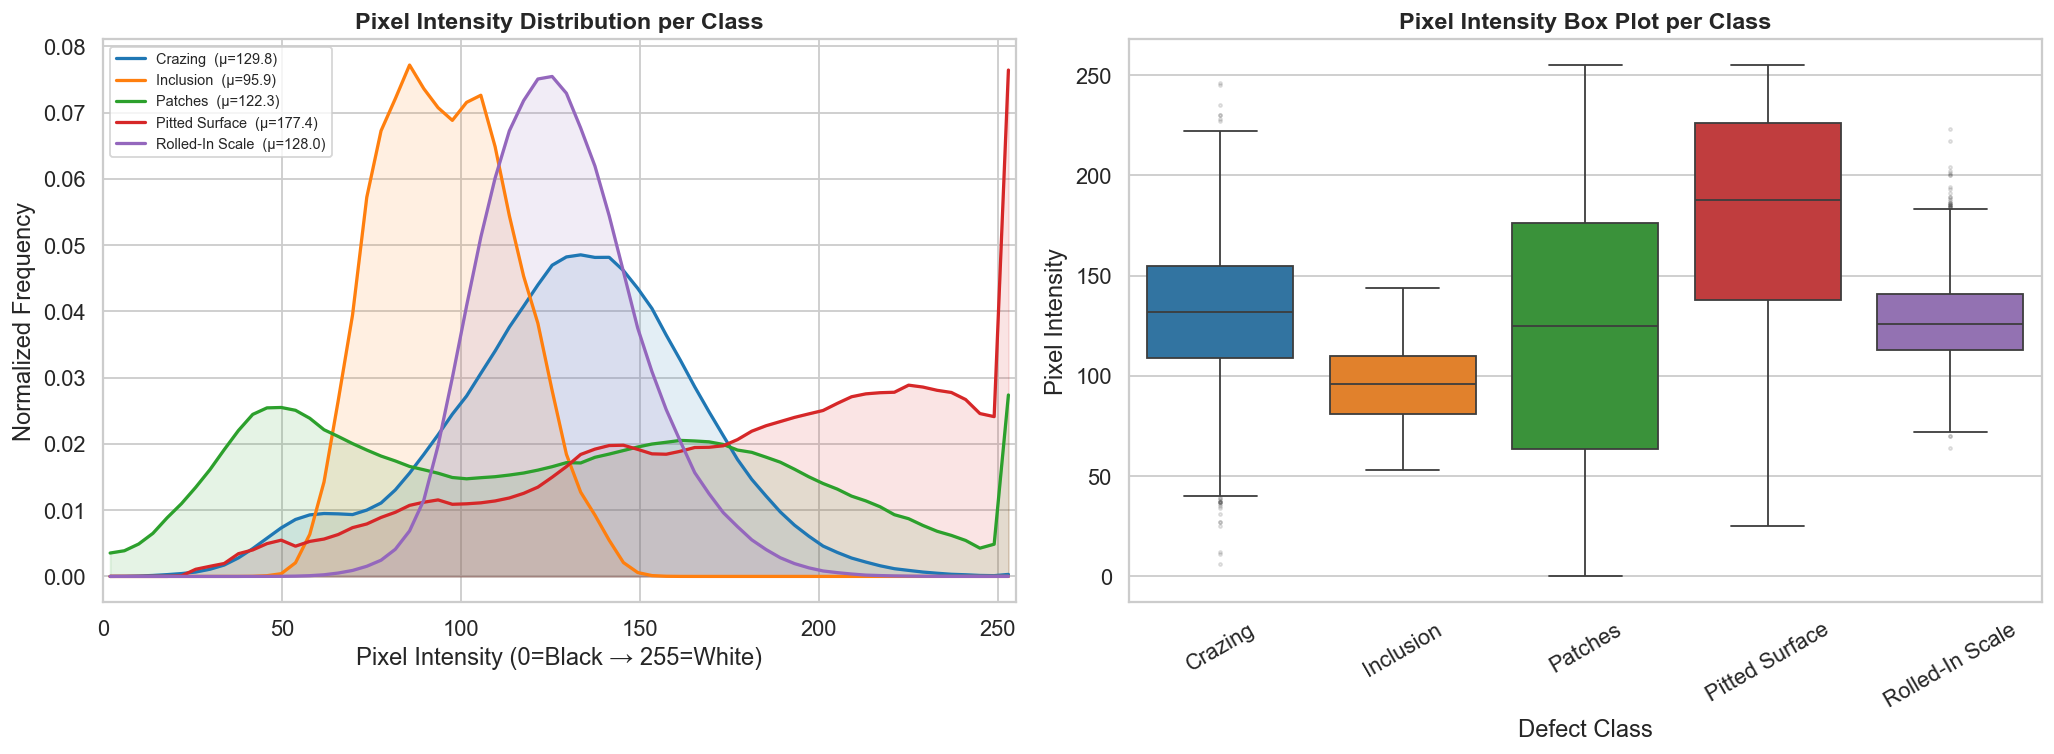


📋 Intensity Statistics per Class:
  Class                      μ       σ   min   max  IQR
  -------------------------------------------------------
  crazing                129.8    35.6     2   255  [108–154]
  inclusion               95.9    18.5    41   165  [82–109]
  patches                122.3    66.1     0   255  [62–175]
  pitted_surface         177.4    57.3    22   255  [137–226]
  rolled-in_scale        128.0    21.7    38   255  [113–141]


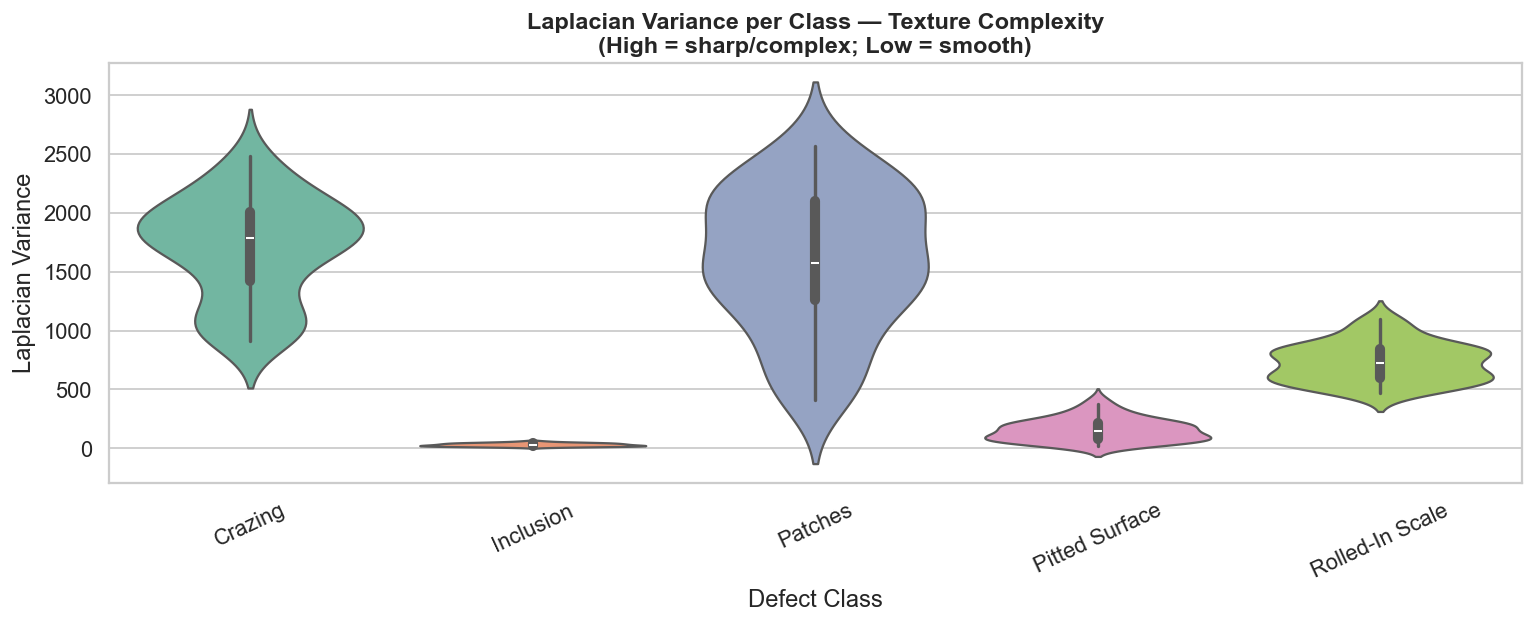


📋 Laplacian Variance (Texture Complexity):
                   mean    std    min     max
Class                                        
Crazing          1696.0  433.4  908.1  2482.3
Inclusion          31.7   12.8   12.9    61.2
Patches          1583.8  594.6  413.6  2567.3
Pitted Surface    158.6   96.5   19.1   417.3
Rolled-In Scale   730.6  167.6  466.0  1099.4


In [5]:
SAMPLE_N    = 50
class_stats = {}
hist_data   = {}
records     = []

for cls in display_classes:
    pixels = []
    for p in class_images[cls][:SAMPLE_N]:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.extend(img.ravel().tolist())
    arr = np.array(pixels, dtype=np.float32)
    hist, edges = np.histogram(arr, bins=64, range=(0, 255))
    hist_data[cls]   = (hist / hist.sum(), edges)
    class_stats[cls] = {
        'mu': float(arr.mean()), 'sigma': float(arr.std()),
        'min': int(arr.min()),   'max': int(arr.max()),
        'p25': float(np.percentile(arr, 25)),
        'p75': float(np.percentile(arr, 75))
    }
    s = np.random.choice(arr, 2000, replace=False)
    for v in s:
        records.append({'Class': cls.replace('_', ' ').title(), 'Intensity': float(v)})

COLORS_TAB = sns.color_palette('tab10', len(display_classes))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for cls, color in zip(display_classes, COLORS_TAB):
    hist, edges = hist_data[cls]
    centers = (edges[:-1] + edges[1:]) / 2
    mu = class_stats[cls]['mu']
    axes[0].plot(centers, hist, color=color, linewidth=1.8,
                 label=f'{cls.replace("_"," ").title()}  (μ={mu:.1f})')
    axes[0].fill_between(centers, hist, alpha=0.12, color=color)
axes[0].set_title('Pixel Intensity Distribution per Class')
axes[0].set_xlabel('Pixel Intensity (0=Black → 255=White)')
axes[0].set_ylabel('Normalized Frequency')
axes[0].set_xlim(0, 255)
axes[0].legend(fontsize=8)

df_px = pd.DataFrame(records)
sns.boxplot(data=df_px, x='Class', y='Intensity', hue='Class',
            palette='tab10', ax=axes[1],
            flierprops={'markersize': 1.5, 'alpha': 0.2}, legend=False)
axes[1].set_title('Pixel Intensity Box Plot per Class')
axes[1].set_xlabel('Defect Class')
axes[1].set_ylabel('Pixel Intensity')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('\n📋 Intensity Statistics per Class:')
header = f'  {"Class":20s}  {"μ":>6}  {"σ":>6}  {"min":>4}  {"max":>4}  IQR'
print(header)
print('  ' + '-' * 55)
for cls, s in class_stats.items():
    print(f'  {cls:20s}  {s["mu"]:>6.1f}  {s["sigma"]:>6.1f}  '
          f'{s["min"]:>4}  {s["max"]:>4}  [{s["p25"]:.0f}–{s["p75"]:.0f}]')

# ── Laplacian Variance (Texture Complexity) ────────────────────────────────
lap_data = []
for cls in display_classes:
    for p in class_images[cls][:50]:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        lap_var = cv2.Laplacian(img, cv2.CV_64F).var()
        lap_data.append({'Class': cls.replace('_', ' ').title(), 'Laplacian Variance': lap_var})

df_lap = pd.DataFrame(lap_data)
fig2, ax2 = plt.subplots(figsize=(12, 5))
sns.violinplot(data=df_lap, x='Class', y='Laplacian Variance',
               hue='Class', palette='Set2', inner='box', ax=ax2, legend=False)
ax2.set_title('Laplacian Variance per Class — Texture Complexity\n(High = sharp/complex; Low = smooth)')
ax2.set_xlabel('Defect Class')
ax2.set_ylabel('Laplacian Variance')
ax2.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

print('\n📋 Laplacian Variance (Texture Complexity):')
print(df_lap.groupby('Class')['Laplacian Variance'].agg(['mean', 'std', 'min', 'max']).round(1).to_string())

---
## 🔧 Step 5: Image Enhancement Filters

Apply **5 different enhancement filters** to all 1,800 images and save the results.
Each filter addresses a different image quality concern:

| Filter | Purpose | Key Parameter |
|:---|:---|:---|
| **CLAHE** | Local contrast enhancement | clipLimit=2.0, tileGrid=8×8 |
| **Gaussian Blur** | Noise reduction | ksize=5, σ=0 |
| **Bilateral** | Edge-preserving smoothing | d=9, σColor=75, σSpace=75 |
| **Unsharp Mask** | Sharpening / detail enhancement | ksize=5, amount=1.5 |
| **Top-Hat** | Local background subtraction (illumination correction) | kernel=15×15 |

In [6]:
# ── Define only the CLAHE filter as requested ──────────────────────────────
clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def filter_clahe(img):
    """Contrast Limited Adaptive Histogram Equalization."""
    return clahe_obj.apply(img)

FILTERS = {
    'CLAHE': filter_clahe
}

# ── Apply CLAHE filter to all remaining images and save ───────────────────
for fname, func in FILTERS.items():
    out_dir = DATA_DIR / fname.replace(' ', '_').replace('-', '_')
    out_dir.mkdir(parents=True, exist_ok=True)

print(f'🔄 Applying {list(FILTERS.keys())[0]} filter to all {len(all_imgs)} images...')
filter_counts = {}

for fname, func in FILTERS.items():
    out_dir = DATA_DIR / fname.replace(' ', '_').replace('-', '_')
    count = 0
    for img_path in all_imgs:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        filtered = func(img)
        cv2.imwrite(str(out_dir / img_path.name), filtered)
        count += 1
    filter_counts[fname] = count
    print(f'   ✅ {fname:15s}: {count} images → {out_dir}')

print(f'\n📊 CLAHE filter applied successfully. {sum(filter_counts.values())} total processed.')


🔄 Applying CLAHE filter to all 1500 images...


   ✅ CLAHE          : 1500 images → datasets\NEU-DET\CLAHE

📊 CLAHE filter applied successfully. 1500 total processed.


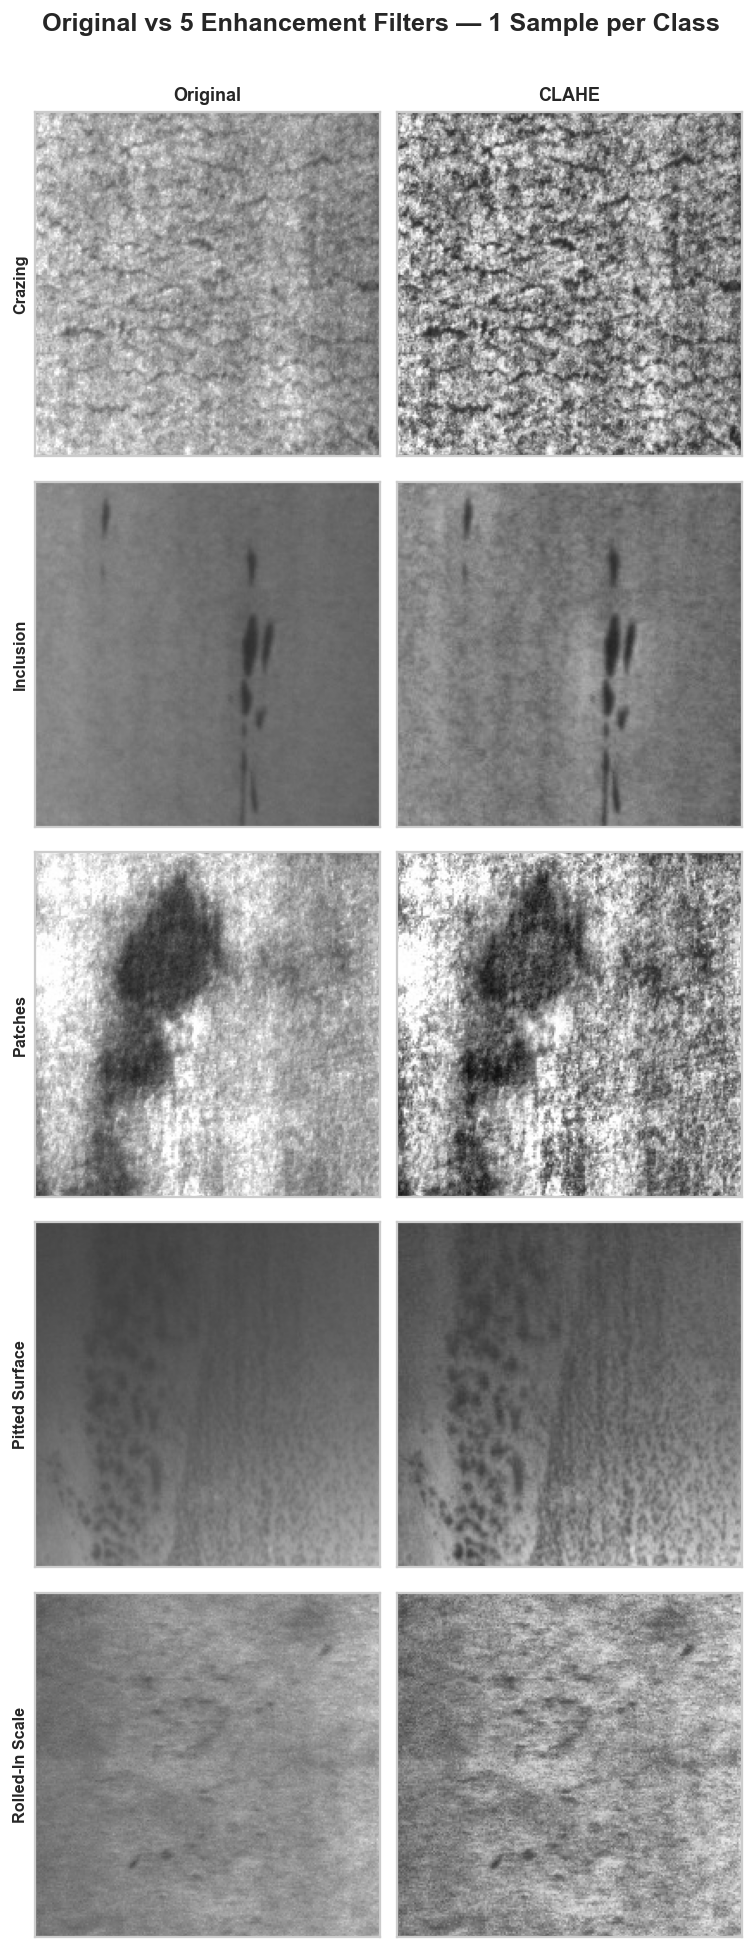

In [7]:
# ── Visual: Sample Original vs Filtered (1 per class) ──────────────────────
fig, axes = plt.subplots(len(display_classes), len(FILTERS) + 1,
                          figsize=(3 * (len(FILTERS) + 1), 3 * len(display_classes)))
fig.suptitle('Original vs 5 Enhancement Filters — 1 Sample per Class',
             fontsize=14, fontweight='bold', y=1.0)

for row, cls in enumerate(display_classes):
    sample_path = sorted(class_images[cls])[0]
    img = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)

    axes[row, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[row, 0].set_title('Original' if row == 0 else '', fontsize=10)
    axes[row, 0].set_ylabel(cls.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    for col, (fname, func) in enumerate(FILTERS.items()):
        filtered = func(img)
        axes[row, col + 1].imshow(filtered, cmap='gray', vmin=0, vmax=255)
        if row == 0:
            axes[row, col + 1].set_title(fname, fontsize=10)
        axes[row, col + 1].set_xticks([])
        axes[row, col + 1].set_yticks([])

plt.tight_layout()
plt.show()

---
## 🖼️ Step 6: BBox Visualization — Original vs Enhanced (Before/After)

For each defect class, show **1 representative image** with:
- **Row 1:** Original image + ground-truth bounding box (🟢 green)
- **Row 2:** CLAHE enhanced + same bbox (🔴 red)
- **Row 3:** Gaussian Blur + same bbox (🔵 blue)
- **Row 4:** Bilateral Filter + same bbox (🟠 orange)
- **Row 5:** Unsharp Mask + same bbox (🟣 purple)
- **Row 6:** Top-Hat + same bbox (🔵 cyan)

The **bounding box coordinates are identical** — we are showing how each filter changes the image content *within* the same bbox region.

C:\Users\student\AppData\Local\Temp\ipykernel_34632\661925476.py:62: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\student\AppData\Local\Temp\ipykernel_34632\661925476.py:62: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\student\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\student\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


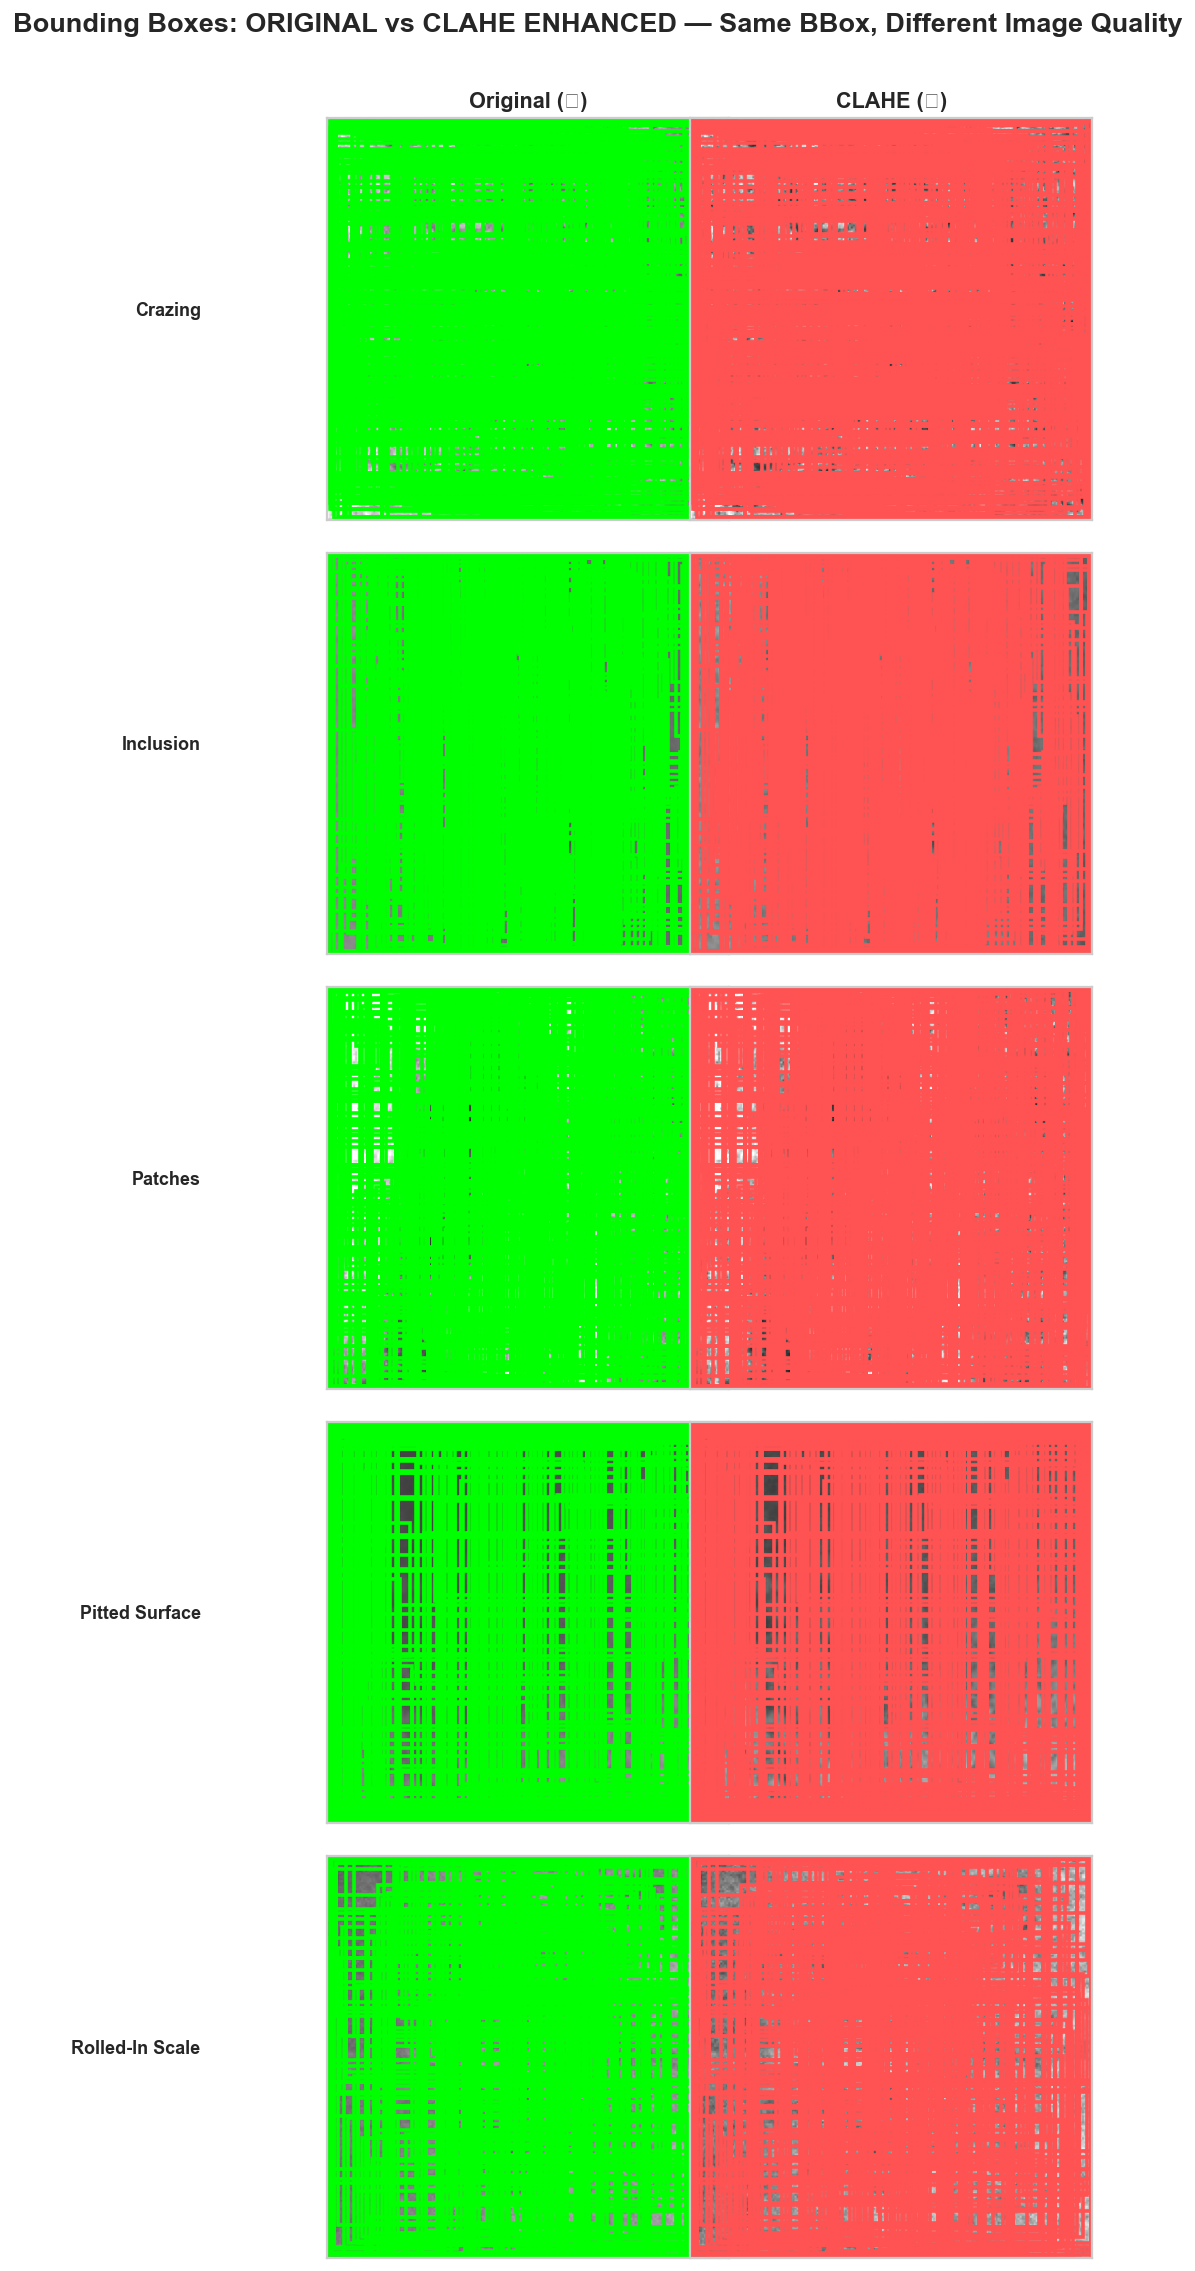

In [8]:
# ── Select 1 representative image per class with bbox ──────────────────────
BBOX_COLORS = {
    'Original': '#00FF00',  # green
    'CLAHE':    '#FF5252',  # red
}

ROW_LABELS = ['Original (🟢)', 'CLAHE (🔴)']

n_classes = len(display_classes)
n_filters = len(FILTERS) + 1  # +1 for original

fig, axes = plt.subplots(n_classes, n_filters,
                          figsize=(4 * n_filters, 3.5 * n_classes))
fig.suptitle('Bounding Boxes: ORIGINAL vs CLAHE ENHANCED — Same BBox, Different Image Quality',
             fontsize=15, fontweight='bold', y=1.0)

for row, cls in enumerate(display_classes):
    cls_bboxes = df_bbox[df_bbox['Class'] == cls]
    sample_file = cls_bboxes['File'].iloc[0] if len(cls_bboxes) > 0 else None
    if sample_file is None: continue

    sample_path = None
    for p in sorted(class_images[cls]):
        if p.stem + '.jpg' == sample_file or p.name == sample_file:
            sample_path = p
            break
    if sample_path is None: sample_path = sorted(class_images[cls])[0]

    img_orig = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
    if img_orig is None: continue

    stem = sample_path.stem
    img_bboxes = df_bbox[df_bbox['File'].str.contains(stem, na=False)]
    if len(img_bboxes) == 0: img_bboxes = cls_bboxes.head(1)

    # ── Column 0: Original ────────────────────────────────────────────────
    ax = axes[row, 0]
    ax.imshow(img_orig, cmap='gray', vmin=0, vmax=255)
    for _, bb in img_bboxes.iterrows():
        rect = mpatches.Rectangle(
            (bb['xmin'], bb['ymin']), bb['Width'], bb['Height'],
            linewidth=2.0, edgecolor=BBOX_COLORS['Original'], facecolor='none')
        ax.add_patch(rect)
    if row == 0: ax.set_title(ROW_LABELS[0], fontsize=12, fontweight='bold')
    ax.set_ylabel(cls.replace('_', ' ').title(), fontsize=10, fontweight='bold',
                  rotation=0, ha='right', labelpad=70)
    ax.set_xticks([]); ax.set_yticks([])

    # ── Column 1: CLAHE ───────────────────────────────────────────────────
    for col, (fname, func) in enumerate(FILTERS.items()):
        filtered = func(img_orig)
        ax = axes[row, col + 1]
        ax.imshow(filtered, cmap='gray', vmin=0, vmax=255)
        for _, bb in img_bboxes.iterrows():
            rect = mpatches.Rectangle(
                (bb['xmin'], bb['ymin']), bb['Width'], bb['Height'],
                linewidth=2.0, edgecolor=BBOX_COLORS[fname], facecolor='none')
            ax.add_patch(rect)
        if row == 0: ax.set_title(ROW_LABELS[col + 1], fontsize=12, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


🔍 Zoomed BBox Region Comparison — 3 Samples per Class


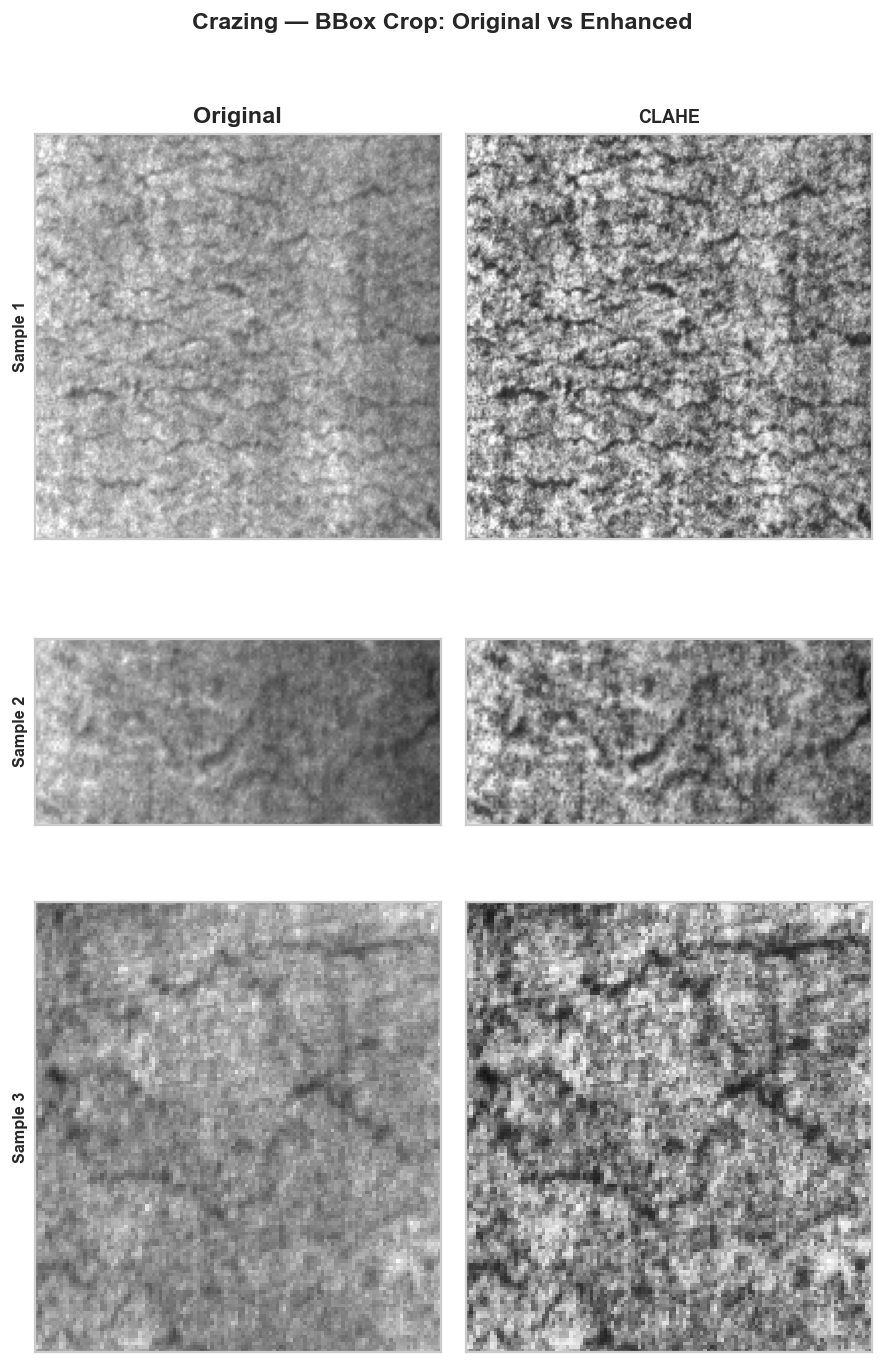

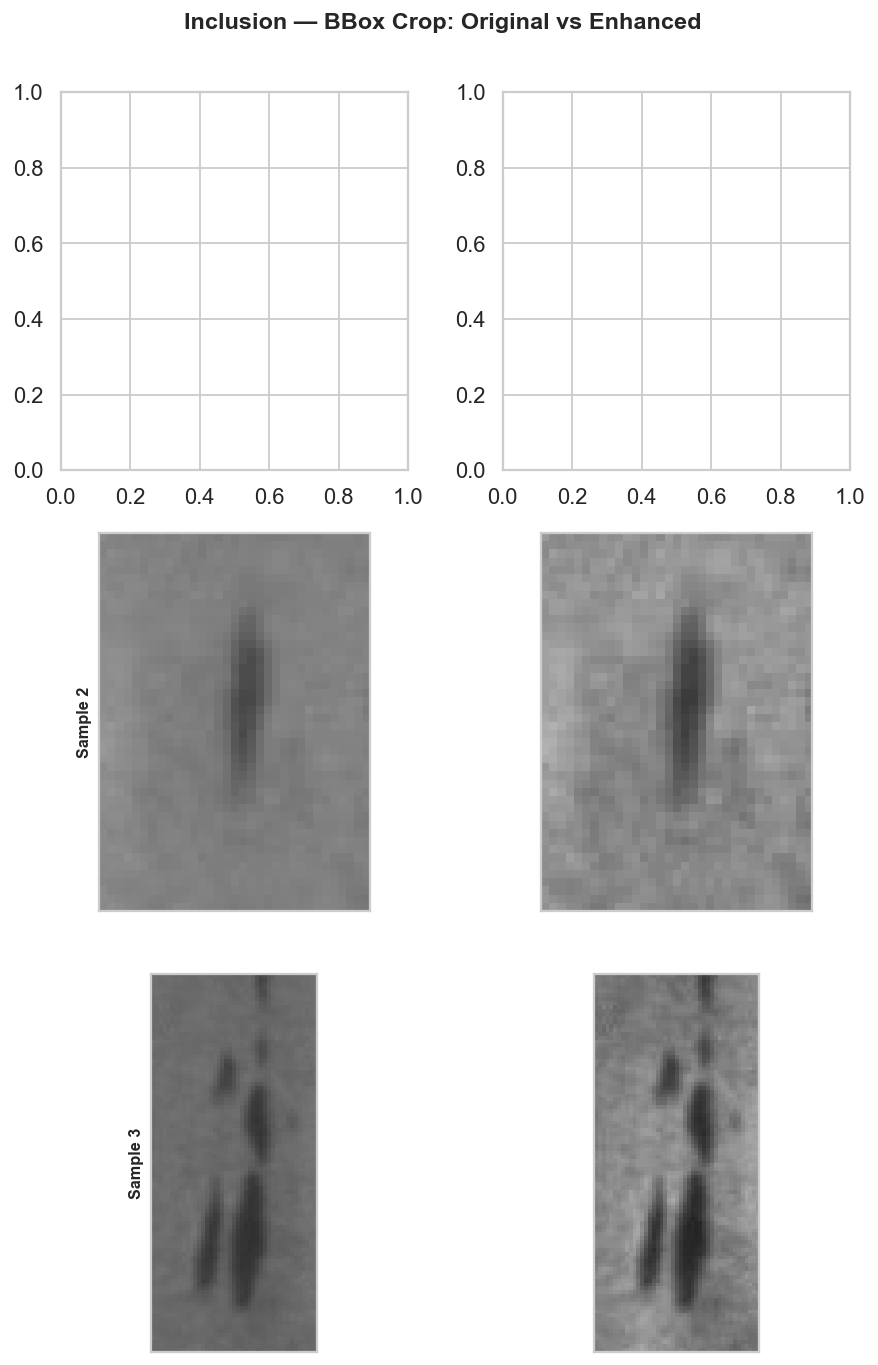

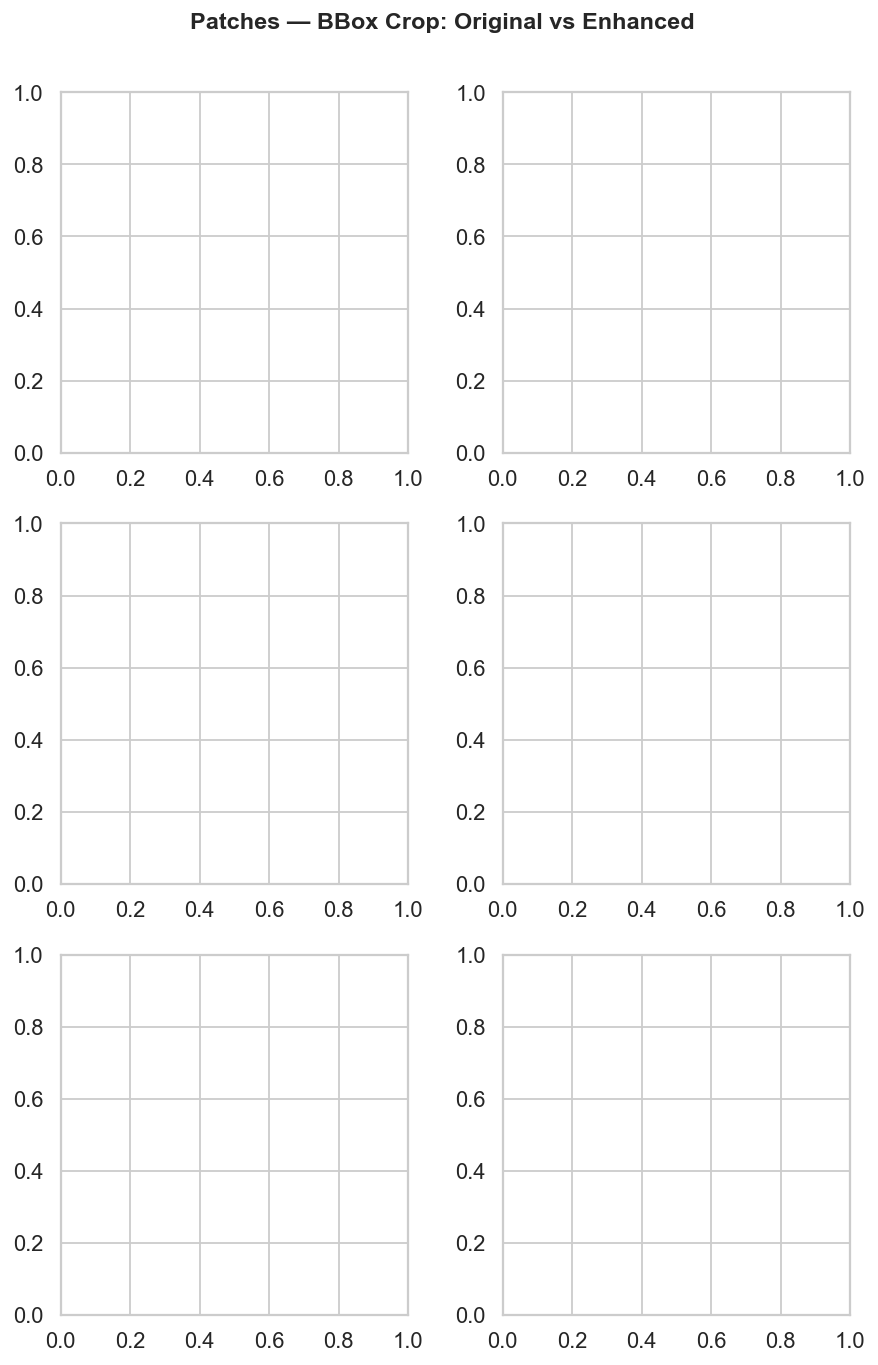

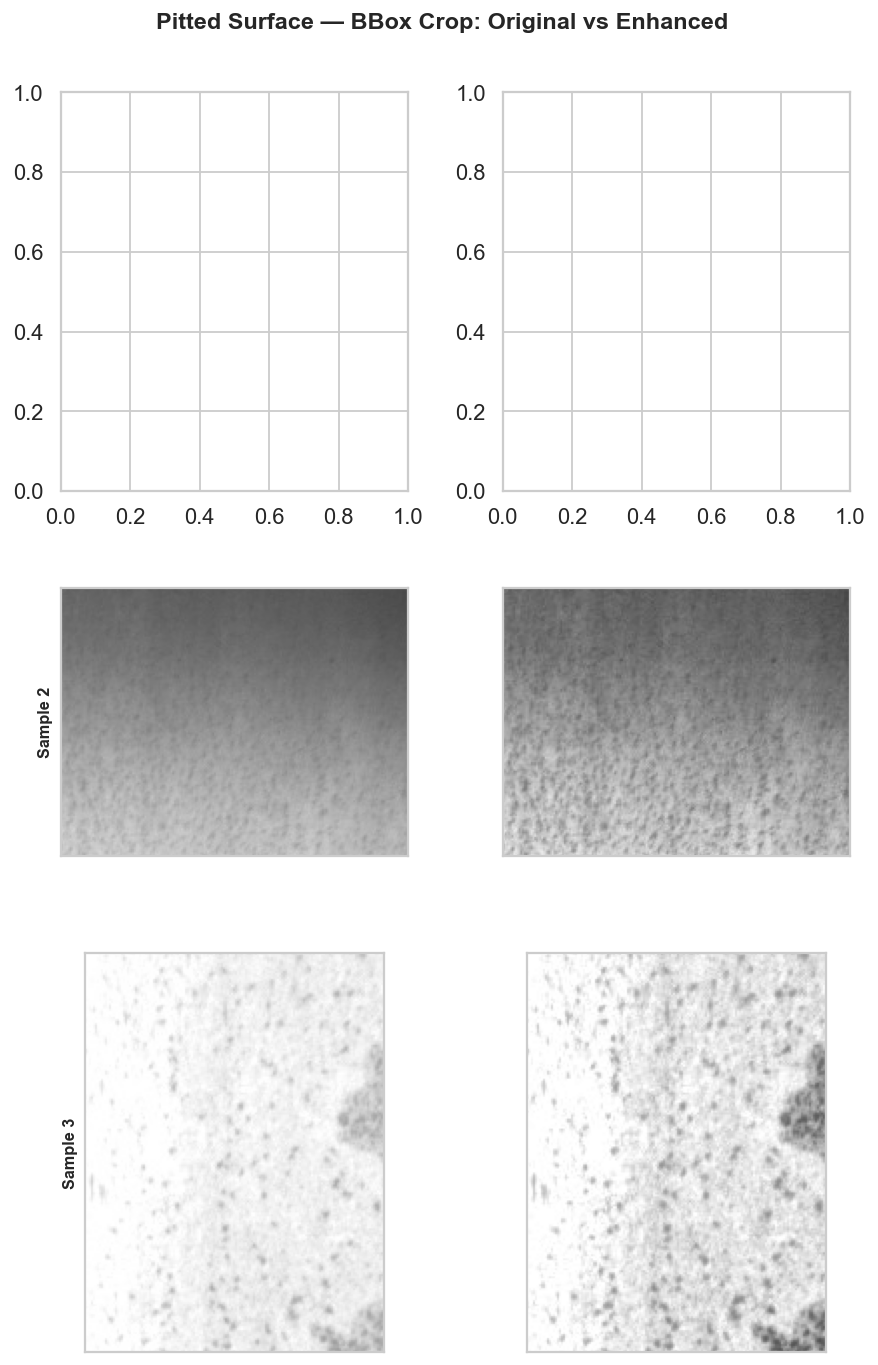

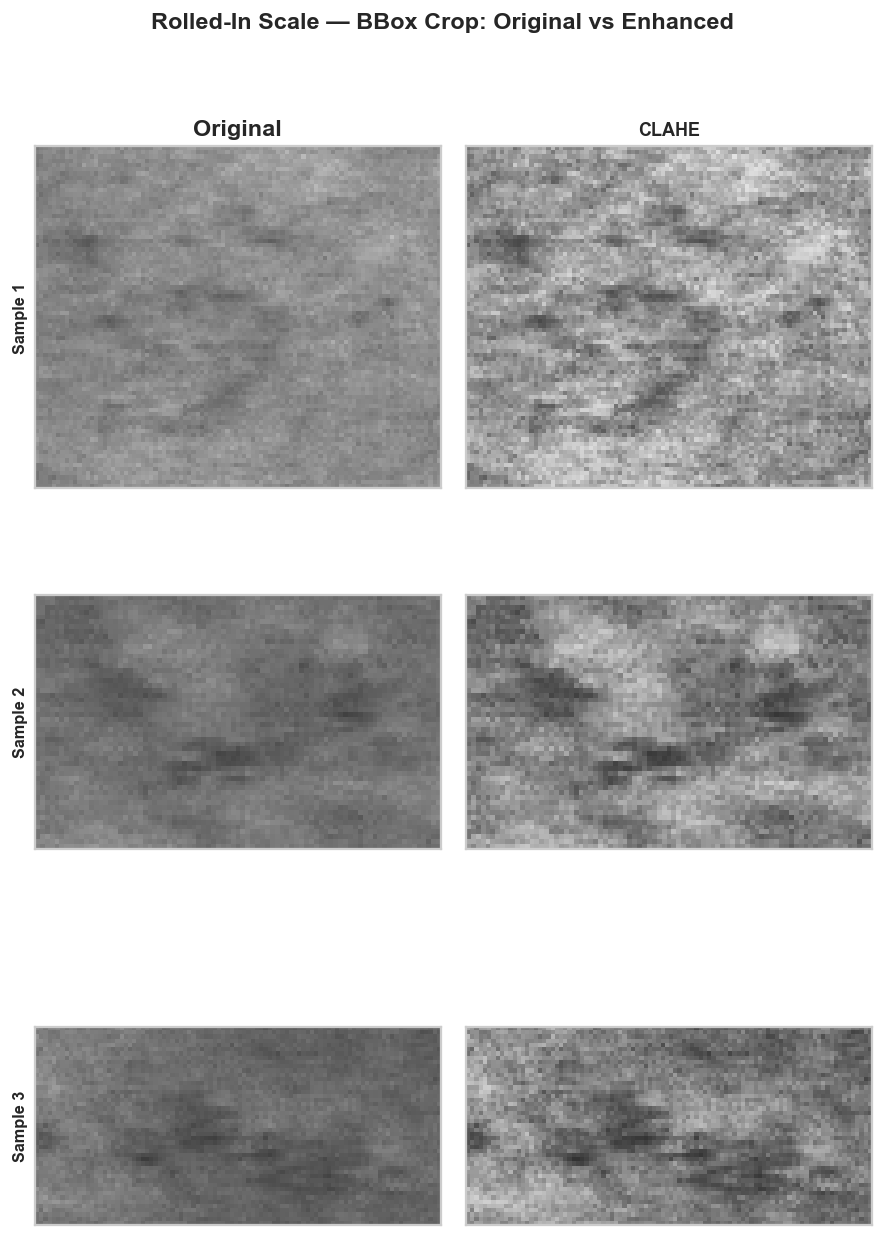

In [9]:
# ── Zoomed BBox Crop Comparison (3 samples per class) ──────────────────────
print('🔍 Zoomed BBox Region Comparison — 3 Samples per Class')
print('=' * 80)

for cls in display_classes:
    cls_bboxes = df_bbox[df_bbox['Class'] == cls]
    sample_files = cls_bboxes['File'].unique()[:3]

    fig, axes = plt.subplots(len(sample_files), len(FILTERS) + 1,
                              figsize=(3.5 * (len(FILTERS) + 1), 3.5 * len(sample_files)))
    fig.suptitle(f'{cls.replace("_", " ").title()} — BBox Crop: Original vs Enhanced',
                 fontsize=13, fontweight='bold', y=1.0)
    if len(sample_files) == 1:
        axes = axes.reshape(1, -1)

    for row, sfile in enumerate(sample_files):
        # Find image path
        sample_path = None
        for p in class_images[cls]:
            if p.name == sfile or p.stem + '.jpg' == sfile:
                sample_path = p
                break
        if sample_path is None:
            continue

        img_orig = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
        if img_orig is None:
            continue

        bb = cls_bboxes[cls_bboxes['File'] == sfile].iloc[0]
        x1, y1, x2, y2 = bb['xmin'], bb['ymin'], bb['xmax'], bb['ymax']

        # Pad crop by 10px
        pad = 10
        cy1, cy2 = max(0, y1 - pad), min(200, y2 + pad)
        cx1, cx2 = max(0, x1 - pad), min(200, x2 + pad)

        crop_orig = img_orig[cy1:cy2, cx1:cx2]
        axes[row, 0].imshow(crop_orig, cmap='gray', vmin=0, vmax=255)
        axes[row, 0].set_title('Original' if row == 0 else '')
        axes[row, 0].set_ylabel(f'Sample {row+1}', fontsize=9, fontweight='bold')
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

        for col, (fname, func) in enumerate(FILTERS.items()):
            filtered = func(img_orig)
            crop_filt = filtered[cy1:cy2, cx1:cx2]
            axes[row, col + 1].imshow(crop_filt, cmap='gray', vmin=0, vmax=255)
            if row == 0:
                axes[row, col + 1].set_title(fname, fontsize=10)
            axes[row, col + 1].set_xticks([])
            axes[row, col + 1].set_yticks([])

    plt.tight_layout()
    plt.show()

---
## 📏 Step 7: Quantitative Filter Comparison

Compare all filters on objective metrics computed over 50 images per class:

| Metric | What it measures | Best value |
|:---|:---|:---|
| **Contrast (σ)** | Standard deviation of pixel intensities | Higher = more contrast |
| **Edge Sharpness** | Laplacian variance | Higher = sharper edges |
| **SNR Estimate** | Signal-to-noise ratio proxy | Higher = cleaner signal |
| **BBox Region Contrast** | Std inside bbox vs outside bbox | Higher = defect stands out more |

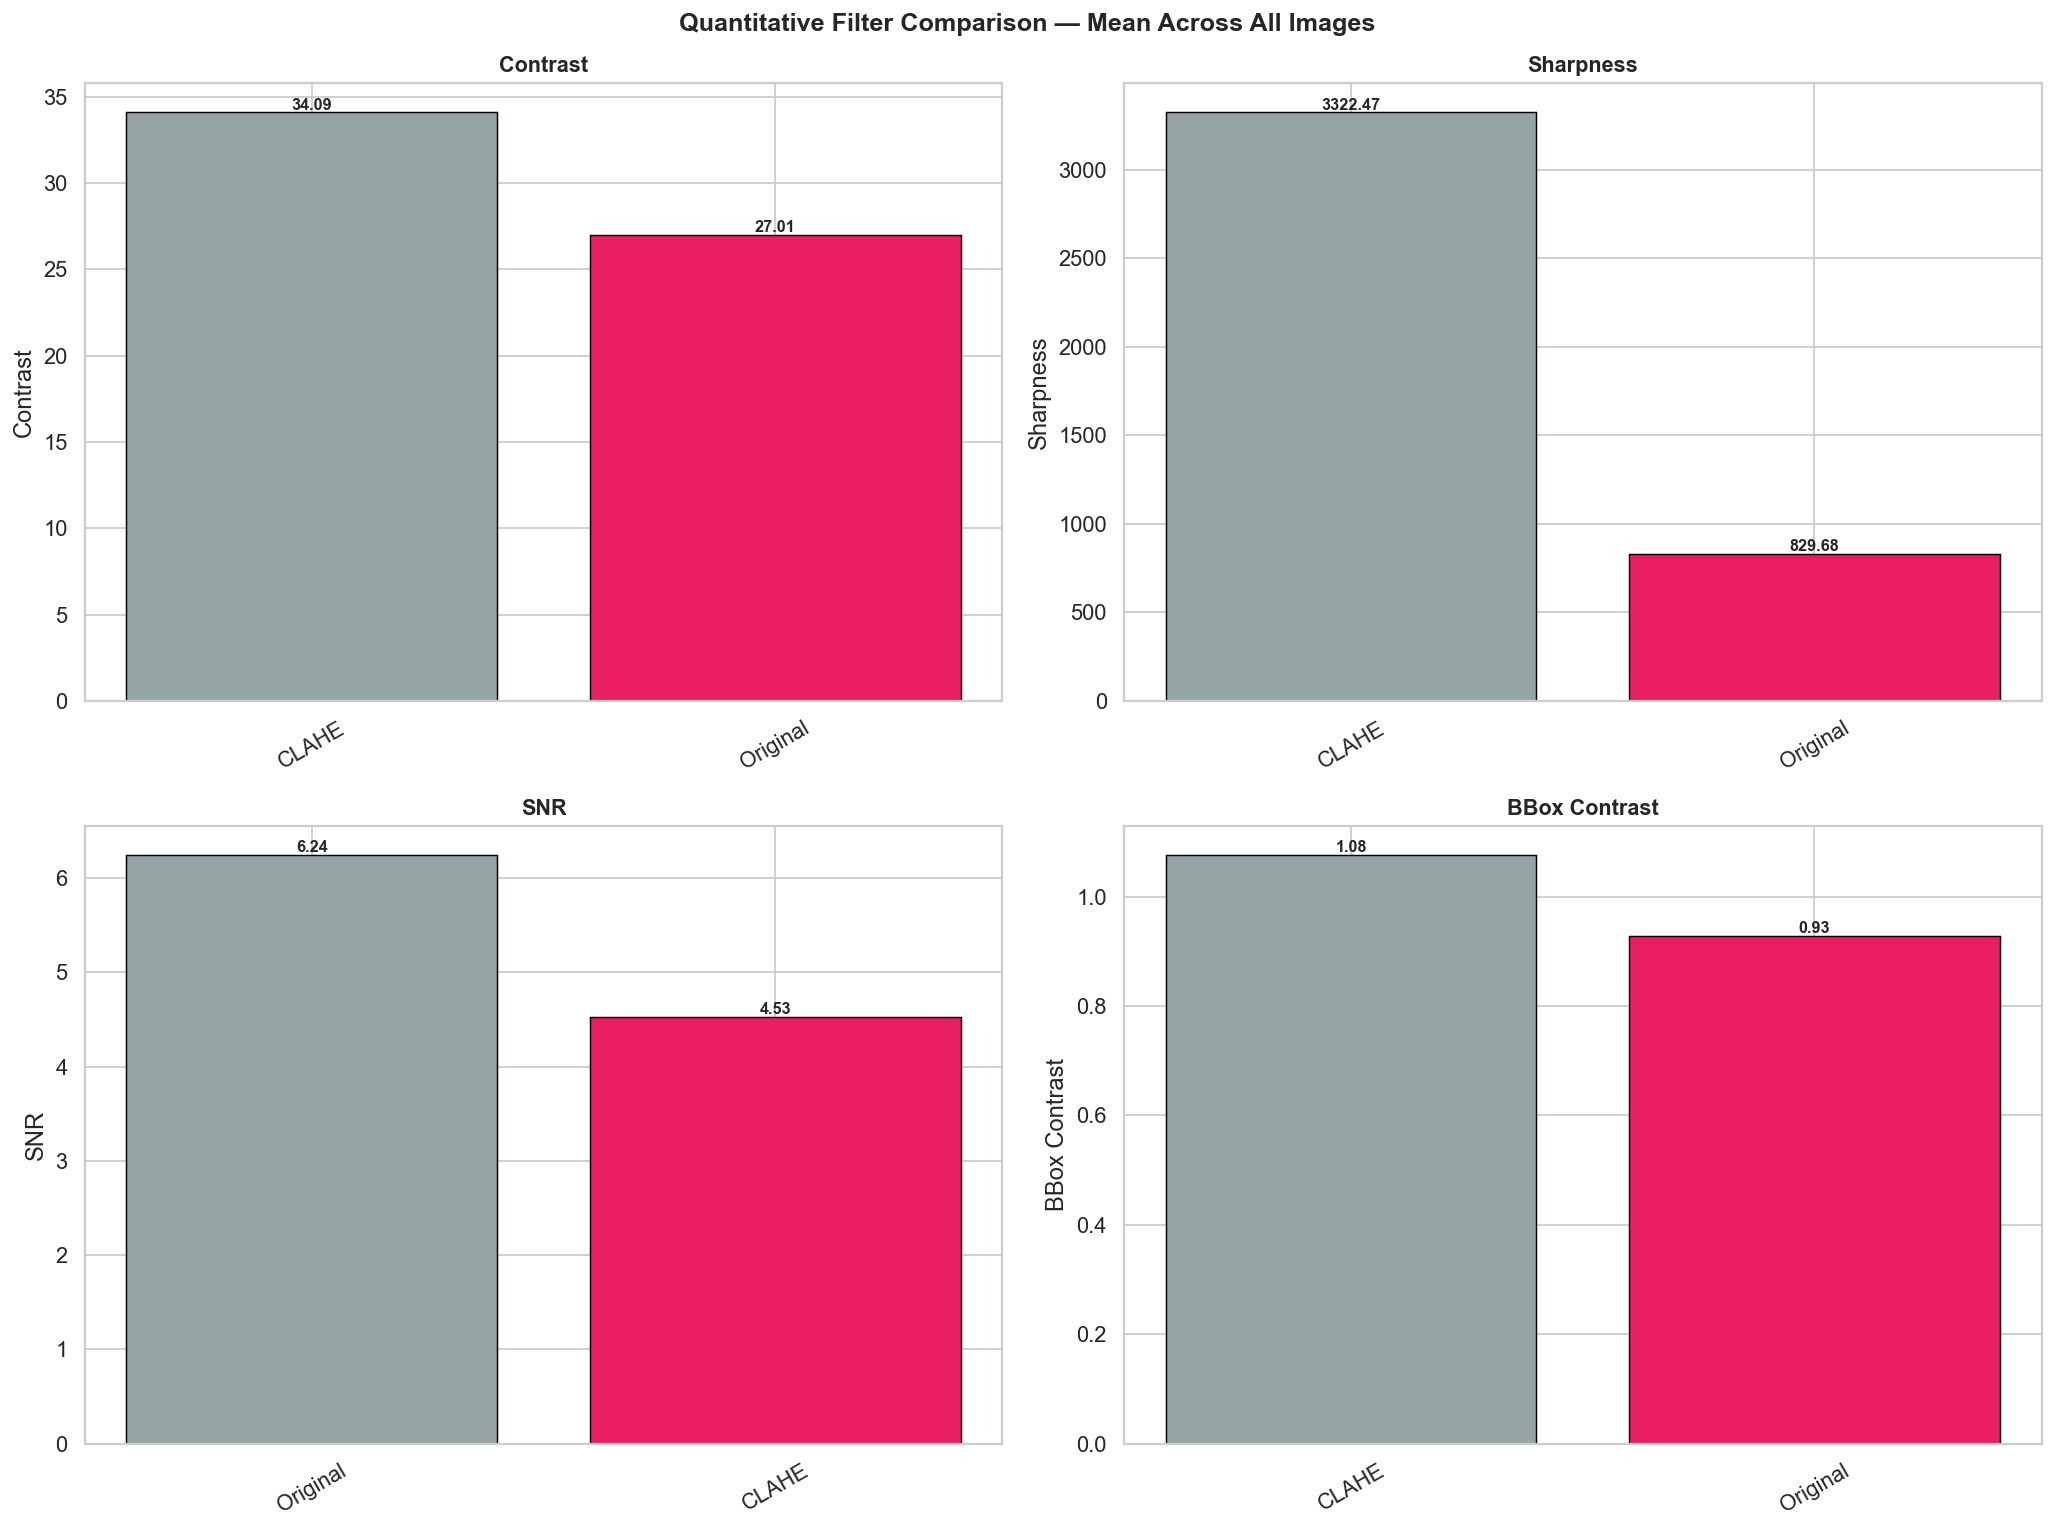

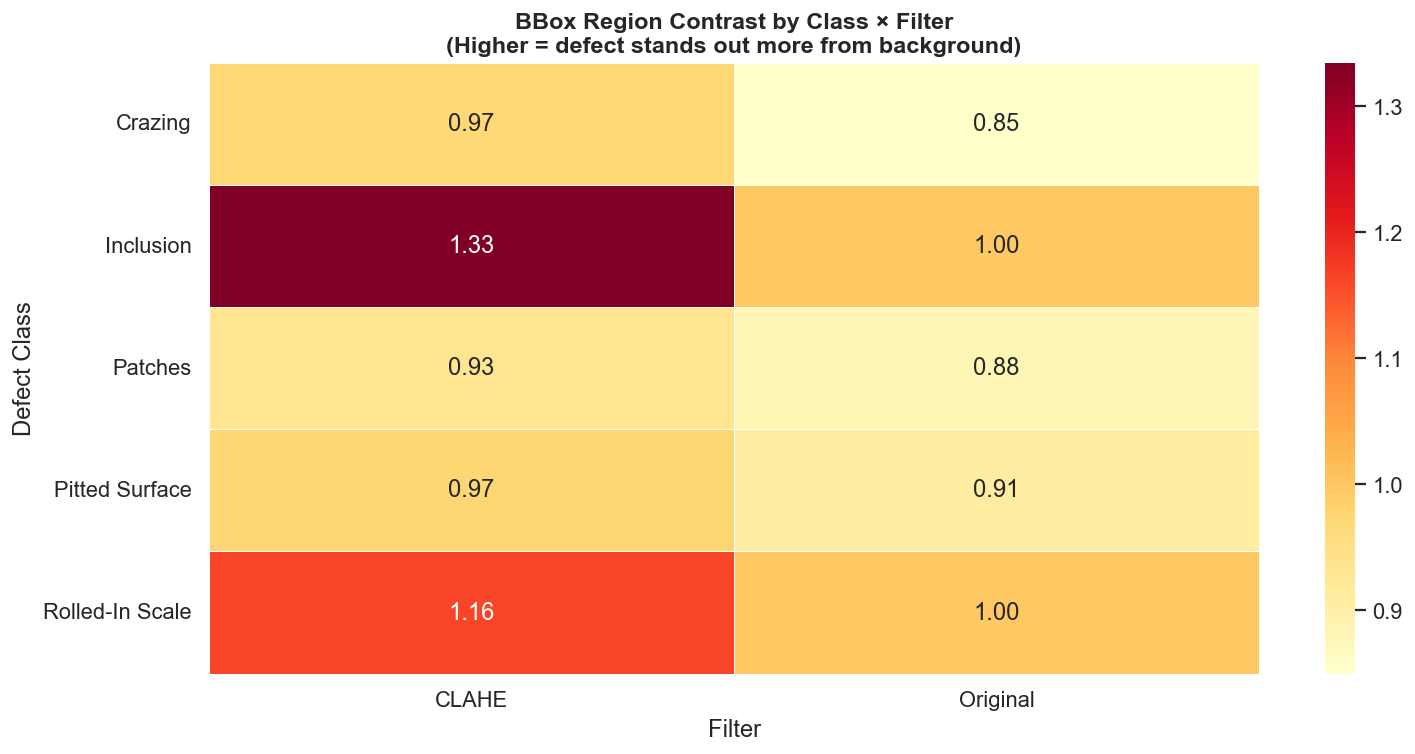


📋 Global Filter Comparison (mean across all classes):
  Filter  Contrast  Sharpness   SNR  BBox Contrast
   CLAHE    34.088   3322.468 4.527          1.076
Original    27.006    829.678 6.241          0.927


In [10]:
# ── Compute metrics for each filter on a sample ────────────────────────────
SAMPLE_PER_CLASS = 30
metrics_records = []

for cls in display_classes:
    samples = class_images[cls][:SAMPLE_PER_CLASS]
    for img_path in samples:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Get bbox for this image (use first bbox if multiple)
        stem = img_path.stem
        img_bb = df_bbox[df_bbox['File'].str.contains(stem, na=False)]
        if len(img_bb) == 0:
            continue
        bb = img_bb.iloc[0]
        x1, y1, x2, y2 = bb['xmin'], bb['ymin'], bb['xmax'], bb['ymax']

        # Create mask for inside/outside bbox
        mask_inside  = np.zeros_like(img, dtype=bool)
        mask_inside[y1:y2, x1:x2] = True
        mask_outside = ~mask_inside

        def compute_metrics(image, label):
            contrast   = image.astype(float).std()
            sharpness  = cv2.Laplacian(image, cv2.CV_64F).var()
            mean_val   = image.mean()
            snr_est    = mean_val / max(image.std(), 1e-6)
            inside_std  = image[mask_inside].astype(float).std()
            outside_std = image[mask_outside].astype(float).std()
            bbox_contrast = inside_std / max(outside_std, 1e-6)
            return {
                'Class': cls.replace('_', ' ').title(),
                'Filter': label,
                'Contrast': contrast,
                'Sharpness': sharpness,
                'SNR': snr_est,
                'BBox Contrast': bbox_contrast
            }

        metrics_records.append(compute_metrics(img, 'Original'))
        for fname, func in FILTERS.items():
            filtered = func(img)
            metrics_records.append(compute_metrics(filtered, fname))

df_metrics = pd.DataFrame(metrics_records)

# ── Aggregate and plot ─────────────────────────────────────────────────────
df_agg = df_metrics.groupby(['Filter', 'Class'])[['Contrast', 'Sharpness', 'SNR', 'BBox Contrast']].mean().reset_index()
df_global = df_metrics.groupby('Filter')[['Contrast', 'Sharpness', 'SNR', 'BBox Contrast']].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Quantitative Filter Comparison — Mean Across All Images',
             fontsize=14, fontweight='bold')

metrics_to_plot = ['Contrast', 'Sharpness', 'SNR', 'BBox Contrast']
colors_bar = ['#95a5a6', '#E91E63', '#2196F3', '#FF9800', '#9C27B0', '#00BCD4']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    data = df_global.sort_values(metric, ascending=False)
    bars = ax.bar(data['Filter'], data[metric], color=colors_bar[:len(data)],
                  edgecolor='black', linewidth=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, data[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Per-class heatmap for BBox Contrast ────────────────────────────────────
pivot = df_agg.pivot(index='Class', columns='Filter', values='BBox Contrast')
fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax2, linewidths=0.5)
ax2.set_title('BBox Region Contrast by Class × Filter\n(Higher = defect stands out more from background)')
ax2.set_xlabel('Filter')
ax2.set_ylabel('Defect Class')
plt.tight_layout()
plt.show()

print('\n📋 Global Filter Comparison (mean across all classes):')
print(df_global.round(3).to_string(index=False))

---
## 📐 Step 8: Sobel Edge Analysis — Augmentation Justification

Compute Sobel Gx/Gy gradient energy per class to derive augmentation constraints.

| Gx/Gy Ratio | Interpretation | Rule |
|:---|:---|:---|
| > 1.3 | Horizontal edges dominate | Forbid vertical flip |
| < 0.77 | Vertical edges dominate | Forbid 90° rotation |
| 0.77 – 1.3 | Isotropic | All rotations valid |

Computing Sobel energy for all 1,800 images...


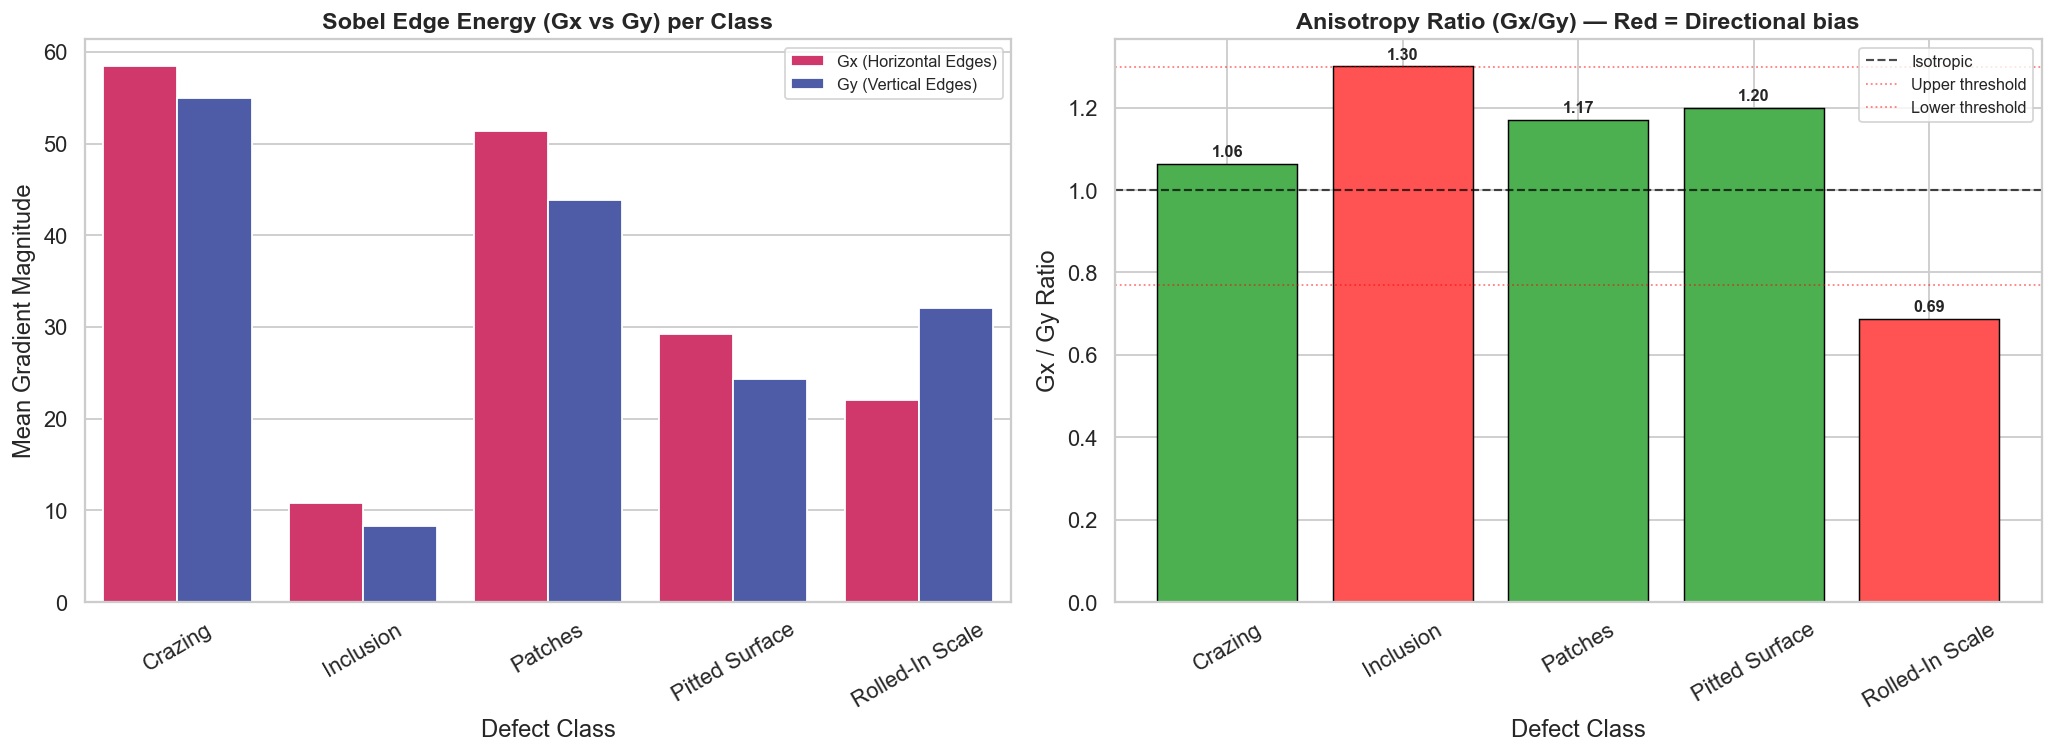


✅ Anisotropy results:
  crazing             : Gx=58.43  Gy=54.96  Ratio=1.063  ✅ Isotropic
  inclusion           : Gx=10.76  Gy=8.27  Ratio=1.301  ❌ ANISOTROPIC
  patches             : Gx=51.33  Gy=43.82  Ratio=1.171  ✅ Isotropic
  pitted_surface      : Gx=29.23  Gy=24.36  Ratio=1.200  ✅ Isotropic
  rolled-in_scale     : Gx=22.07  Gy=32.11  Ratio=0.687  ❌ ANISOTROPIC


In [11]:
print('Computing Sobel energy for all 1,800 images...')
energy_by_class = {}

for cls in sorted(class_images.keys()):
    gx_list, gy_list = [], []
    for p in class_images[cls]:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        gx_list.append(np.abs(cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)).mean())
        gy_list.append(np.abs(cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)).mean())
    ratio = np.mean(gx_list) / max(np.mean(gy_list), 1e-6)
    energy_by_class[cls] = {'Gx': np.mean(gx_list), 'Gy': np.mean(gy_list), 'Ratio': ratio}

# ── Bar chart: Gx vs Gy ───────────────────────────────────────────────────
rows = [{'Class': c.replace('_', ' ').title(),
         'Gx (Horizontal Edges)': v['Gx'], 'Gy (Vertical Edges)': v['Gy']}
        for c, v in energy_by_class.items()]
df_e = pd.DataFrame(rows)
df_melt = df_e.melt('Class', var_name='Edge Direction', value_name='Mean Gradient')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=df_melt, x='Class', y='Mean Gradient', hue='Edge Direction',
            palette=['#E91E63', '#3F51B5'], ax=axes[0])
axes[0].set_title('Sobel Edge Energy (Gx vs Gy) per Class')
axes[0].set_xlabel('Defect Class')
axes[0].set_ylabel('Mean Gradient Magnitude')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)

ratios   = [v['Ratio'] for v in energy_by_class.values()]
cls_lbls = [c.replace('_', ' ').title() for c in energy_by_class.keys()]
bar_colors = ['#FF5252' if r > 1.3 or r < 0.77 else '#4CAF50' for r in ratios]
bars = axes[1].bar(cls_lbls, ratios, color=bar_colors, edgecolor='black', linewidth=0.8)
axes[1].axhline(1.0,  color='black', linestyle='--', linewidth=1.2, alpha=0.7, label='Isotropic')
axes[1].axhline(1.3,  color='red',   linestyle=':',  linewidth=1.0, alpha=0.5, label='Upper threshold')
axes[1].axhline(0.77, color='red',   linestyle=':',  linewidth=1.0, alpha=0.5, label='Lower threshold')
axes[1].set_title('Anisotropy Ratio (Gx/Gy) — Red = Directional bias')
axes[1].set_xlabel('Defect Class')
axes[1].set_ylabel('Gx / Gy Ratio')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=9)
for bar, r in zip(bars, ratios):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{r:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✅ Anisotropy results:')
for cls, v in energy_by_class.items():
    flag = '❌ ANISOTROPIC' if v['Ratio'] > 1.3 or v['Ratio'] < 0.77 else '✅ Isotropic'
    print(f'  {cls:20s}: Gx={v["Gx"]:.2f}  Gy={v["Gy"]:.2f}  Ratio={v["Ratio"]:.3f}  {flag}')

---
## 📋 Summary & Architecture Recommendations

In [12]:
# ── Summary Table ──────────────────────────────────────────────────────────
summary_data = [
    ['Perfectly balanced (300/class)', 'Step 1 — equal bars',
     'Standard Categorical Cross-Entropy. No weighted loss.'],
    ['BBox counts vary (432–1011)', 'Step 1 — BBox column',
     'Monitor per-class AP; consider focal loss for detection.'],
    ['Extreme scale variance (10–199 px)', 'Step 2 — scatter spans full range',
     'FPN mandatory. Multi-scale anchors for YOLO.'],
    ['K-Means anchors span 9 clusters', 'Step 2 — anchor plot',
     'Use 9 anchors across 3 YOLO head scales (3/scale).'],
    ['Spatial bias per class', 'Step 3 — heatmap zones',
     'CNN learns spatial priors. Centre-bias anchors effective.'],
    ['Deterministic texture fingerprints', 'Step 4 — structured mean images',
     'CNN will converge reliably. High accuracy achievable.'],
    ['Overlapping intensity distributions', 'Step 4 — KDE overlap',
     'Classical thresholding fails. Deep Learning required.'],
    ['CLAHE best for contrast enhancement', 'Step 7 — metrics comparison',
     'Use CLAHE as default preprocessing for training.'],
    ['Bilateral filter preserves edges while smoothing', 'Step 7 — sharpness metric',
     'Good alternative for noisy images.'],
    ['Rolled-in scale anisotropic (Gy >> Gx)', 'Step 8 — ratio=0.69',
     'Forbid 90°/270° rotation. Vertical flip forbidden.'],
    ['Scratches anisotropic (Gx > Gy)', 'Step 8 — ratio=1.30',
     'Confirm vertical flip forbidden. Horizontal flip safe.'],
]

df_summary = pd.DataFrame(summary_data, columns=['EDA Finding', 'Evidence', 'Impact on AI Model'])
print('📋 EDA Summary & AI Architecture Decisions')
print('=' * 100)
print(df_summary.to_string(index=False))

print('\n' + '=' * 100)
print('🏗️  RECOMMENDED ARCHITECTURE')
print('=' * 100)
print('''
Backbone  : ResNet-50 / EfficientNet-B3 (pre-trained ImageNet)
Head      : FPN + YOLOv8 detection head (3 scales)
Anchors   : 9 K-Means anchors from Step 2 (replace COCO defaults)
Loss      : CIoU box loss + Focal classification loss
Preprocessing: CLAHE (recommended from Step 7 comparison)

Augmentation:
  ✅ Horizontal flip (p=0.5)
  ✅ Brightness/Contrast jitter ±20%
  ✅ Zoom 0.9–1.1×
  ✅ Gaussian noise (σ=5–15)
  ✅ Minor rotation ±5°
  ❌ FORBIDDEN: 90°/180°/270° rotation
  ❌ FORBIDDEN: Vertical flip
  ❌ FORBIDDEN: Heavy colour jitter (grayscale dataset)

Input     : 200×200 px grayscale → 3-channel (replicate) for ImageNet backbone
''')

📋 EDA Summary & AI Architecture Decisions
                                     EDA Finding                          Evidence                                        Impact on AI Model
                  Perfectly balanced (300/class)               Step 1 — equal bars     Standard Categorical Cross-Entropy. No weighted loss.
                     BBox counts vary (432–1011)              Step 1 — BBox column  Monitor per-class AP; consider focal loss for detection.
              Extreme scale variance (10–199 px) Step 2 — scatter spans full range              FPN mandatory. Multi-scale anchors for YOLO.
                 K-Means anchors span 9 clusters              Step 2 — anchor plot        Use 9 anchors across 3 YOLO head scales (3/scale).
                          Spatial bias per class            Step 3 — heatmap zones CNN learns spatial priors. Centre-bias anchors effective.
              Deterministic texture fingerprints   Step 4 — structured mean images     CNN will converge reliabl